# Lab 074 · CARTE cross-table transfer

**Skill:** follow schema-variable rows through a source-checked CARTE encoder and evaluate real transferred embeddings against matched scratch controls. **Scope:** exact single-readout released architecture, selected YAGO weights, real cached FastText vectors; different downstream head/training from the paper. Three Tier-A wine datasets × three seeds × six arms. Full benchmark INCOMPARABLE.

PROVIDED exposes the architecture and trainer; TODO holds three live functions; CHECK gives immediate feedback; EXIT requires measurements and explanation.

[Lesson](../lessons/0074-carte-cross-table-transfer.html) · [Reproduction contract](../labs/l074-reproduction.md)

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Before reading: retrieve the boundary

Close the previous lesson. Write three short answers: What comparison isolates pretraining from architecture? Which rows may fit a numerical transform? Why can a positive gain at one label budget fail at another? Keep your answers, then retain your answers for tutor review.



**Your tangible win.** Given a row from a table with unfamiliar columns, draw the graph CARTE consumes, trace how column meaning changes one message, and design a fair test of whether a pretrained encoder helps a small target table. The companion lab makes you implement graph construction, attention normalization and validation-only probe selection.

The route is **row → typed messages → shared encoder → target prediction → transfer audit**. Allow one focused reading session and a separate lab session. Ask the tutor about any step you cannot reconstruct; bring your graph and intermediate values.

<!-- depth-walkthrough:start -->
<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · LESSON 074</p><p><strong>Build on what you know.</strong> <a href="https://avistian.github.io/relational/lessons/0072-scarf-subtab-contrastive-views.html">Lesson 72</a> aligned views of the same row. <a href="https://avistian.github.io/relational/lessons/0073-when-ssl-helps.html">Lesson 73</a> held schema fixed. CARTE changes the representation itself so a shared encoder can consume different column sets; contrast this with the fixed column token positions of Lessons 44–46.</p><p><strong>The next question.</strong> <a href="https://avistian.github.io/relational/lessons/0075-pytorch-frame-row-encoder.html">Lesson 75</a> returns to explicit semantic types and fitted conversion state. CARTE makes schema flexibility visible; PyTorch Frame makes the modular row-encoding interface visible.</p><p><a href="https://avistian.github.io/relational/reference/0071-0090-model-map.html">Open the SSL → relational → graph model map</a> · Work the cold retrieval first, then spend 15–20 minutes tracing this overview before the detailed mechanism and lab.</p></div>



## Transfer a computation, not a column position

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Architecture diagram; scroll horizontally on narrow screens">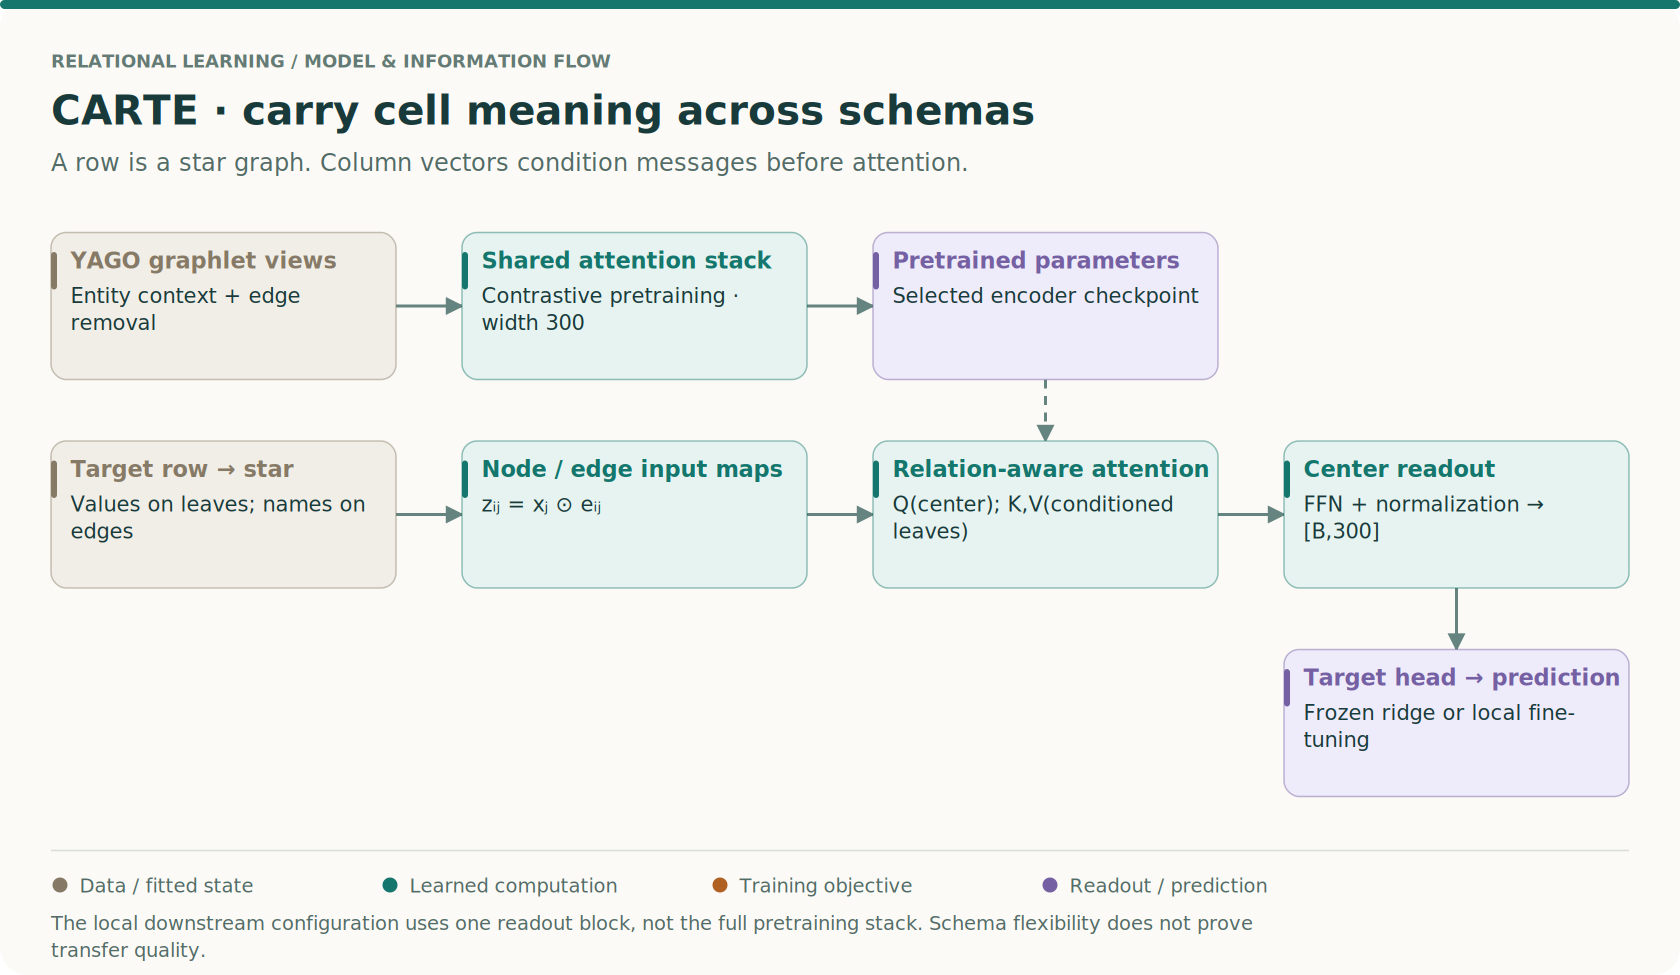</div><figcaption>Read the arrows as data dependencies. Teal: learned computation; amber: training objective; violet: readout or prediction. This is a computation overview; exact settings and paper/release differences are specified below.</figcaption></figure>

### Paper reading: separate three transfers

Read [CARTE Figures 1–3 and §§3.1–3.3](https://arxiv.org/html/2402.16785v2). Mark background-graph pretraining, target-table prediction, and supervised source-table transfer as different stages. The pretrained object is a parameter set. The target row does not retrieve and attach its entire YAGO neighborhood during this local forward pass.

### Reconstruct the target-row path

1. **Create the facts.** For a text value, keep its value embedding and its column-name embedding as separate objects. For a number, use its train-transformed scalar to scale the column embedding. The value “4” is not meaningful without its role and units.
2. **Create the structure.** Attach each observed cell to a row center. If a value is missing, omit that leaf. A present numerical zero still has an edge and column identity, so missingness and zero are distinguishable even when a leaf vector is zero.
3. **Condition before scoring.** Multiply sender and relation vectors coordinatewise before projecting keys and values. With sender [2,3] and relation [1,0], the conditioned vector is [2,0]. Changing the relation to [0,1] gives [0,3] without changing the raw value vector. This is how the column role enters the message.
4. **Normalize over the right neighborhood.** Each row center competes only among its own incoming messages. If another row is appended to a batch, that alone must not steal probability mass from the first row's cells. The segmented-softmax CHECK tests this independently of prediction quality.
5. **Read out one center.** The graph encoder returns a row vector after attention and the node block. The target predictor sees that vector. A frozen ridge probe updates no encoder weights; local fine-tuning does. Comparing these arms asks whether adaptation helps, while comparing pretrained and random encoders asks whether transferred weights help.

<details><summary>Predict: does permuting columns always preserve the answer?</summary><p>Reordering complete value–column pairs preserves the represented facts and should preserve the center readout up to numerical tolerance. Permuting values while holding column labels fixed changes those facts and should not be treated as a symmetry.</p></details>

**Your intermediate artifact:** draw a two-cell star for an unfamiliar schema, list its node and edge tensor shapes, then label which parameters came from pretraining. Consult the code-versus-paper center-initialization audit below before calculating its center: the pinned release and paper description differ.

<!-- depth-walkthrough:end -->



## 1. The unresolved question from Lesson 73

[Lesson 73](../lessons/0073-when-ssl-helps.html) held one table's feature representation fixed while changing the amount of supervision. Its central comparison was the same network with and without self-supervised pretraining. That experiment leaves another problem: how can parameters learned on one collection of columns accept a different collection?

A **schema** describes the columns of a table, including their names and types. A network whose first layer takes `[age, income, city]` cannot directly interpret `[winery, rating, country, vintage]`: the number and meanings of its input coordinates have changed. Padding the shorter row solves the length problem but leaves the meanings unspecified.

**Schema matching** explicitly determines which columns across sources correspond. **Entity matching** explicitly determines which records or names refer to the same real-world thing. Both can be valuable, and both can be expensive or ambiguous. For example, `country` and `nation` might correspond; two wines with nearly identical names might still be different vintages.

> **In plain terms.** CARTE turns each observed cell into a value paired with a description of its role. A shared graph encoder reads any number of such pairs. The learned parameters no longer have one separate input position for every column in every table.

CARTE expands to *Context Aware Representation of Table Entries*. Read [the paper, especially Figures 1–3 and Sections 3.1–3.3](https://arxiv.org/html/2402.16785v2). Keep [the pinned released model](https://github.com/soda-inria/carte/blob/f54690da4cddbedd1e1a9113a312f85783d2c125/carte_ai/src/carte_model.py) open for the implementation audit. We will separate the model's ability to accept a schema from evidence that useful knowledge transfers to it.



## 2. Turn one row into a small graph

### Values and roles have separate vectors

An **embedding** is a numerical vector representing an input such as a string. FastText represents words using learned word and character-subword information; the released CARTE converter uses its sentence-vector operation for strings. The input dimension is 300. This operation accepts new strings, although semantic quality depends on language, spelling and domain. See [the FastText documentation](https://fasttext.cc/docs/en/english-vectors.html) and [the actual converter](https://github.com/soda-inria/carte/blob/f54690da4cddbedd1e1a9113a312f85783d2c125/carte_ai/src/carte_table_to_graph.py).

A **node** holds a value vector. An **edge** connects two nodes and holds a relation vector. In a row graph, the relation describes the column. The **center** is an extra node representing the entire row; each observed cell is a **leaf**, a node attached to that center. This is a star graph. A **graphlet** here means this small local graph, not a new database table.

For a text cell, use the embedding of its value as the leaf vector. Use the embedding of its column name as the edge vector. For a numerical cell, first transform its scalar value using statistics fitted on training rows. Multiply that scalar by the column vector to obtain its leaf vector. Thus a number's representation carries its role: a rating of 4 and a volume of 4 need not have the same vector.

A missing value contributes no leaf. A zero contributes a leaf with a zero numerical vector and a present relation. Missing and zero therefore give different graph structures. If every value is missing, the mean used for the center is undefined. Our lab raises an error so the application must choose and document a fallback.

### Worked example: distinguish two means

Use a two-dimensional teaching embedding, independent of the real 300-dimensional FastText cache. Let `colour → [1, 2]`, `red → [2, −1]`, and `volume → [3, 1]`. The row contains colour=`red`, transformed volume=`2`, and a missing region.

The leaves are `[2, −1]` and `2 × [3, 1] = [6, 2]`. The paper's plain leaf average is `[4, 0.5]`. The pinned released converter instead averages **edge-conditioned** leaves: `[1, 2] ⊙ [2, −1] = [2, −2]` and `[3, 1] ⊙ [6, 2] = [18, 2]`. Its center is `[10, 0]`. The symbol `⊙` means coordinate-by-coordinate multiplication. The drawing focuses on messages entering the center; the executable graph additionally includes leaf self-messages with an all-ones relation vector.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable graph figure">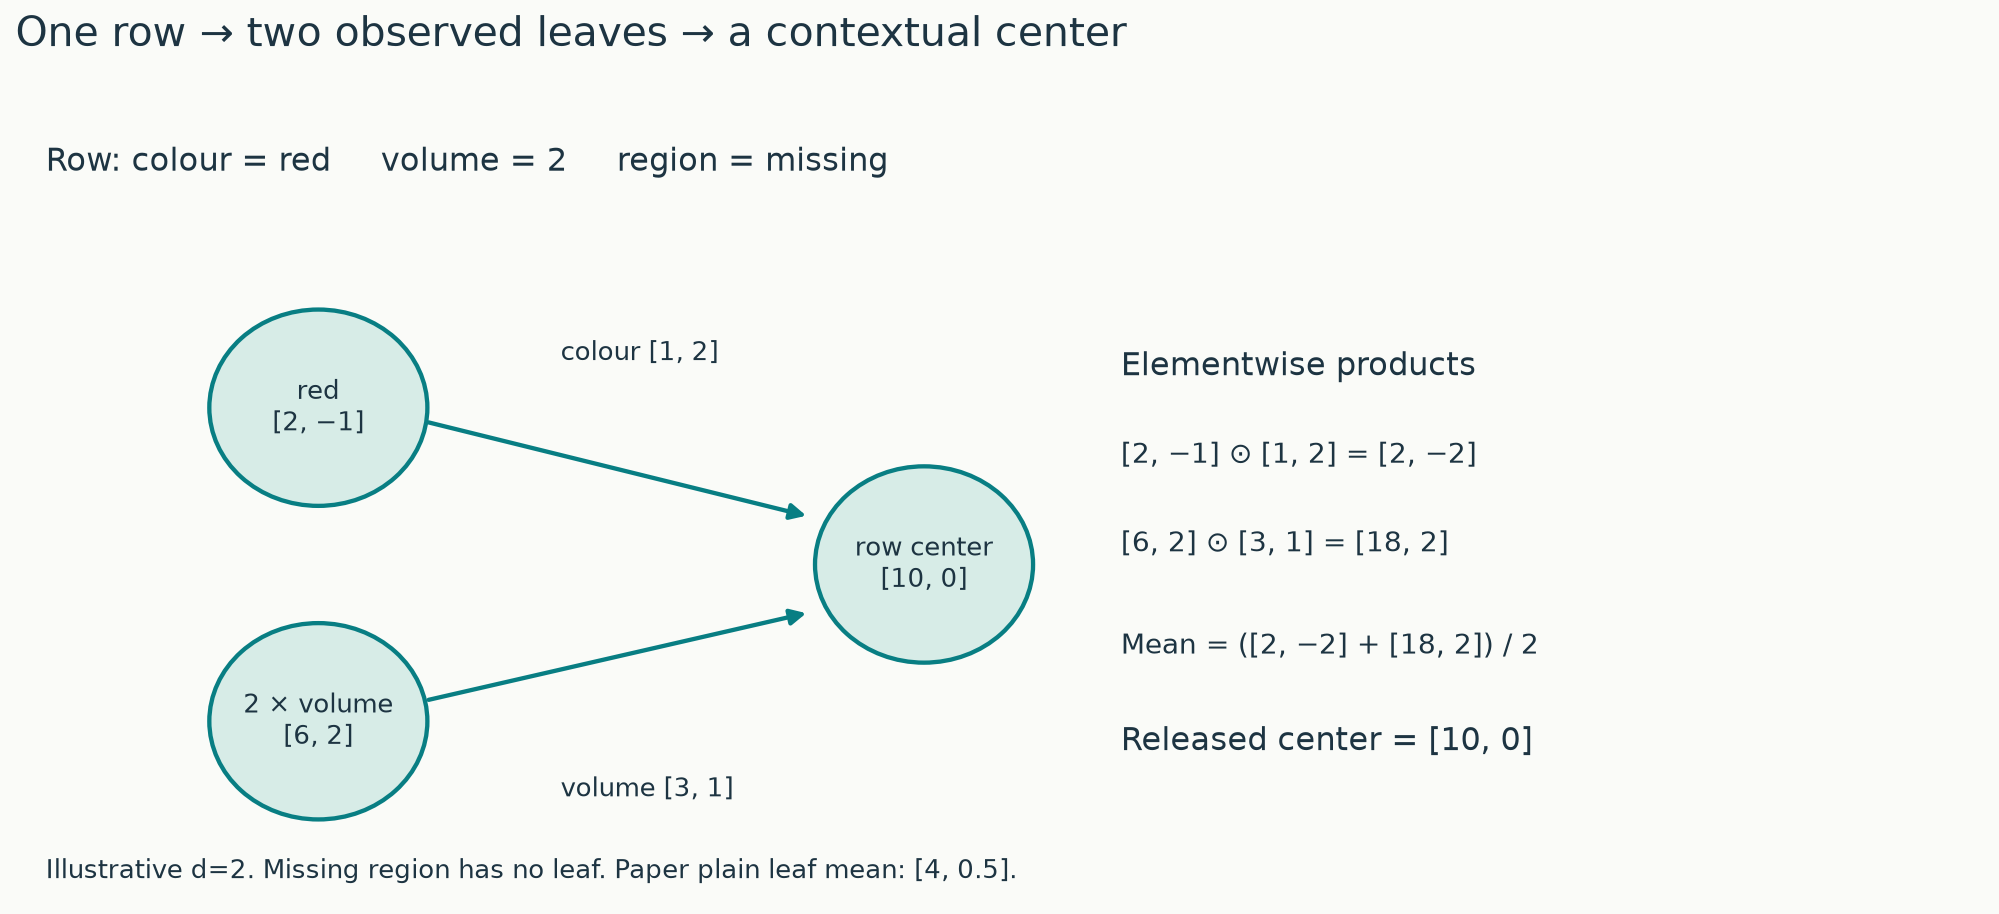</div><figcaption>Illustrative two-dimensional row encoding. Trace the value-edge products before averaging. The real cache uses 300 coordinates. On narrow screens, scroll horizontally.</figcaption></figure>

> **Source audit.** Paper Section 3.1 describes the center as the leaf mean. The pinned converter computes `Z = edge_attr * x[edge_index[1]]` and averages the messages addressed to node 0. The lab follows this released computation. We retain both values above so the implementation choice is explicit.

Predict what happens when volume becomes missing, then calculate the new center on paper. Also predict what happens when the same volume is assigned a different column vector. The toy vectors expose arithmetic; they do not claim to encode real linguistic similarity.



**Graph dimensions.** With two observed cells, there are three nodes. The release converter creates two leaf-to-center messages plus one self-message per leaf, so its index tensor has shape `2 × 4`. Node and edge feature matrices have shapes `3 × 300` and `4 × 300`. In this code, the first row of the index tensor names the receiver; the second names the sender. Read these roles from the actual indexing operation rather than assuming a library convention.



## 3. Model architecture: follow the entire solution

### From background facts to target rows

**Pretraining** learns reusable parameters before target labels are used. CARTE's background source is YAGO, a knowledge graph containing triples such as `(Louvre, located in, Paris)`. A triple has a subject, relation and object. Its local neighborhoods can be represented with node and relation vectors of the same dimensions as the row graphs.

For pretraining, a neighborhood can extend two hops: one hop traverses one relation edge, and two hops reach a neighbor of a neighbor. This background graph contains richer structure than the one-row stars used downstream.

Two views of an entity graph provide a positive pair. One view removes a random subset of edges. Other entities in the batch provide negative examples. A **contrastive objective** trains representations of the positive pair to agree while distinguishing other examples. Recall [Lesson 72](../lessons/0072-scarf-subtab-contrastive-views.html): changing the view-construction rule changes which variations the representation learns to tolerate.

For a similarity score `s`, a temperature `τ > 0`, anchor `a`, and positive `p`, the generic InfoNCE form is `−log(exp(s(a,p)/τ) / Σ_b exp(s(a,b)/τ))`. The denominator contains the positive and eligible negatives; the anchor itself is excluded. Deleting edges teaches partial-context consistency. It does not automatically teach every synonym or unit conversion.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable architecture figure">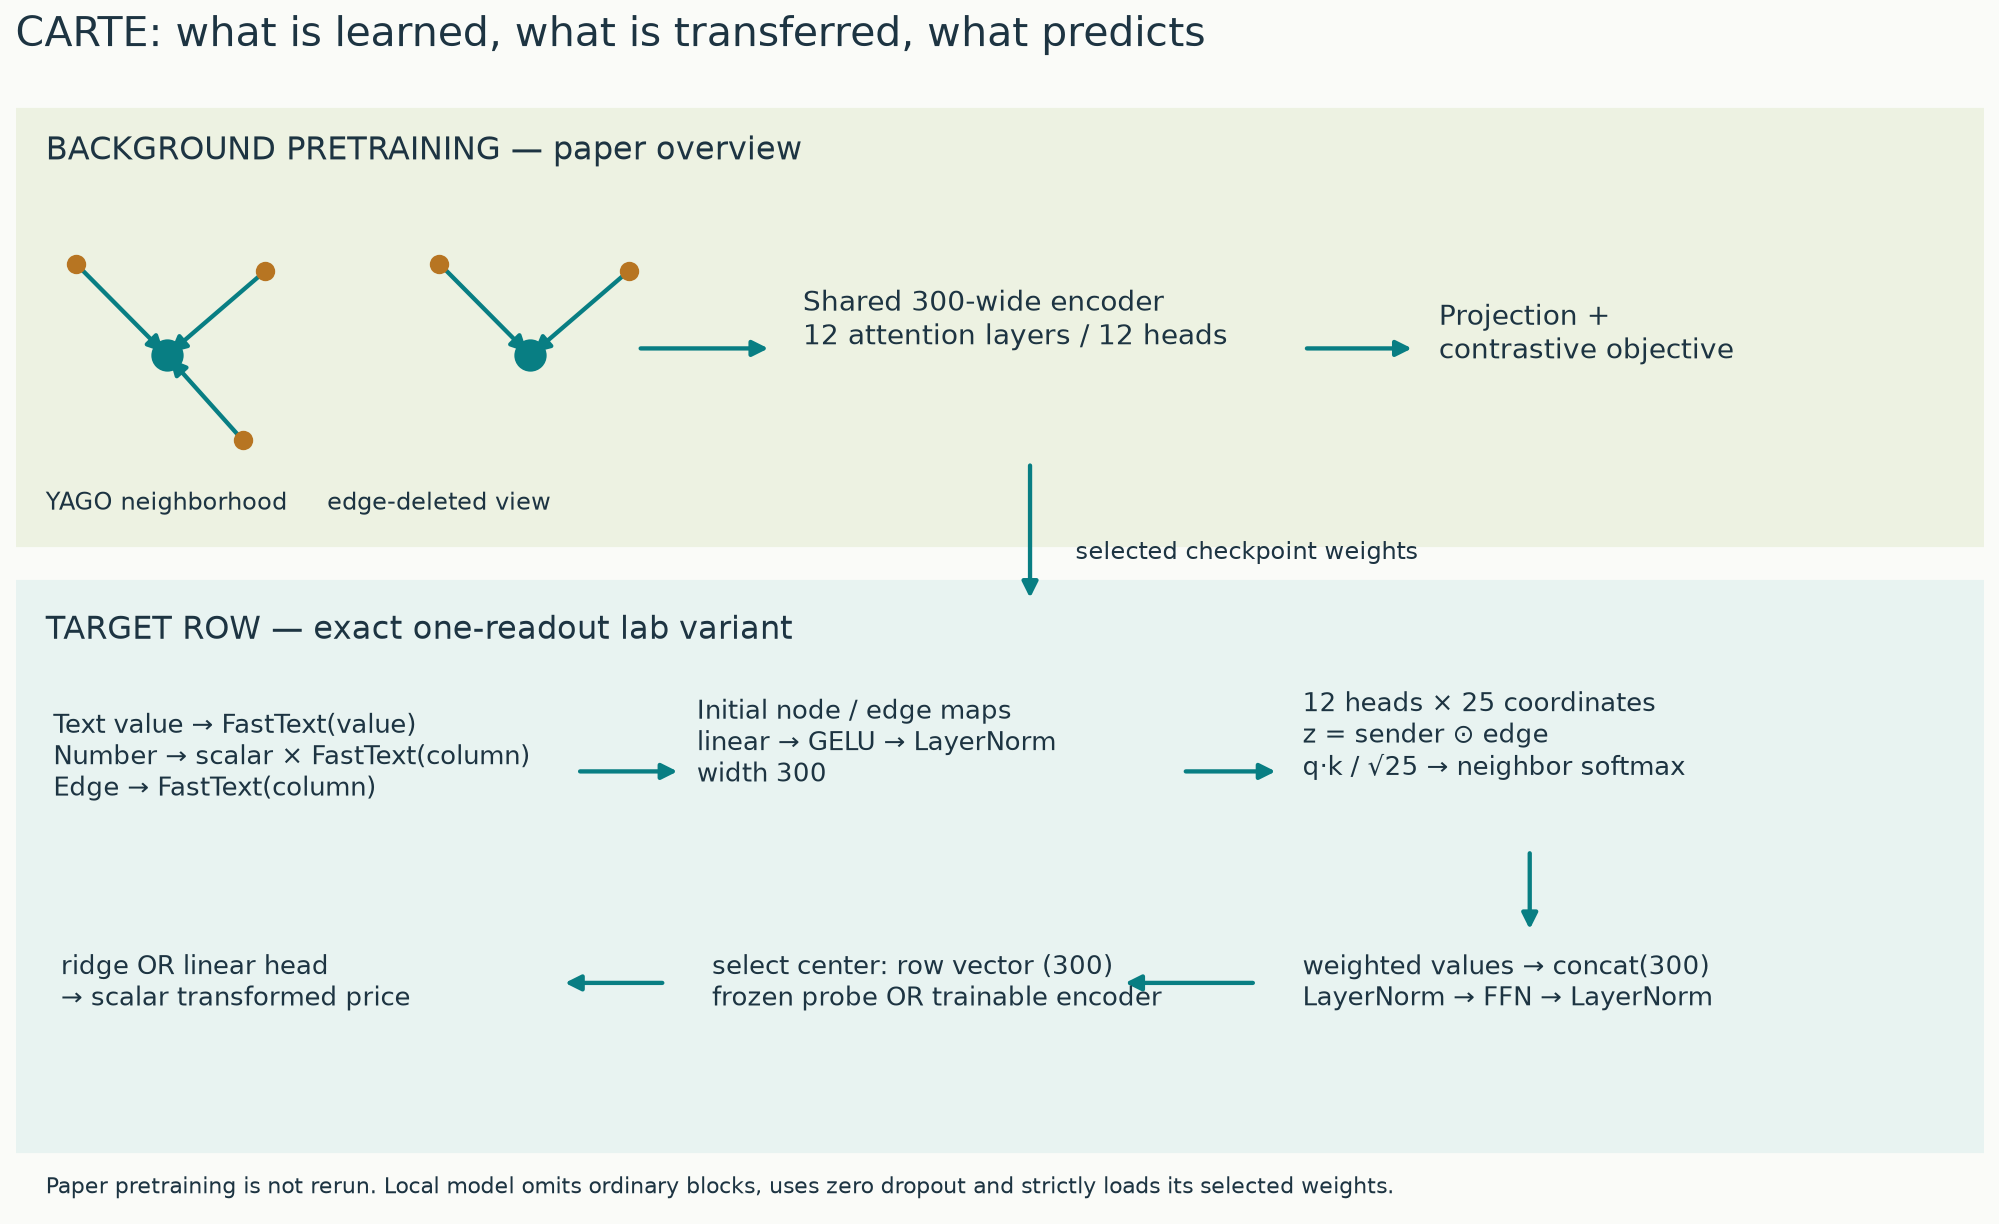</div><figcaption>Complete pretraining-to-prediction route. Upper lane: paper pretraining overview. Lower lane: the exact single-readout local encoder and its two target adaptation choices. On narrow screens, scroll horizontally.</figcaption></figure>

**Read the upper lane.** Background graphlets share the encoder. The paper's pretraining stack has 12 attention layers, 12 heads and width 300. An output projection supplies the contrastive objective. Parameters, not the sampled background graphlets, move to downstream prediction.

**Read the lower lane.** A target row becomes a star graph. Separate learned linear maps, GELU activations and layer normalization transform node and edge inputs. A linear map mixes coordinates using learned weights. GELU is a smooth nonlinearity. Layer normalization centers and rescales coordinates within each node or edge, with learned scale and offset. These operations keep each input vector at width 300 in this implementation.

The lab uses the release's one-readout downstream configuration: initial maps → graph attention → node normalization → two-layer feed-forward network → node normalization → center selection. It uses 12 attention heads, each of width 25. Concatenating their outputs restores width 300. A **readout** extracts the center vector, giving one row embedding. The lab computes only those final center outputs during training; it still uses every observed leaf as an input message. The full forward pass remains visible, and output plus gradient checks verify that this execution shortcut preserves the model. A target head then turns that vector into a scalar prediction.

A **frozen probe** keeps encoder weights fixed and fits a target predictor on the embeddings. **Fine-tuning** updates the encoder as well as a new target head. Our frozen predictor is ridge regression; our fine-tuning predictor is a learned linear head. The feed-forward network (FFN) is a two-layer map applied separately to each node. An **ensemble** averages or otherwise combines predictions from multiple trained models. The paper's training and ensemble recipe differs, so compare matched local arms before making claims about the original benchmark.

> **Source audit.** The pinned estimator uses `num_layers − 1` ordinary blocks before its readout. Its default `num_layers=1` therefore leaves zero ordinary blocks. It also renames `initial_x` checkpoint keys before loading with `strict=False`, leaving that input map uninitialized from the checkpoint. This lab deliberately loads **all selected encoder keys strictly**, including `initial_x`. Architecture parity is checked separately from this weight-loading choice. The source release's node block has no residual addition; we do not silently insert a standard Transformer residual.

### Trace the load-bearing attention computation

> **In plain terms.** Each cell sends a proposal to the center. The column vector changes that proposal before attention decides its weight.

Let `x_j` denote the sender's vector and `e_ij` the relation vector for the message from `j` to receiver `i`. First calculate `z_ij = x_j ⊙ e_ij`. Three learned matrices make a **query**, a vector describing what the receiver seeks; a **key**, a vector used to score a proposal; and a **value**, the content to be averaged:

`q_i = W_Q x_i`, `k_ij = W_K z_ij`, `v_ij = W_V z_ij`.

For one head of width `d_h`, its logit is `q_i · k_ij / √d_h`. A dot product multiplies corresponding coordinates and sums them. The square-root factor controls the growth of score magnitude with dimension. Softmax exponentiates these logits and divides by their sum **over neighbors of the same receiver**. The resulting weights sum to one for that receiver. The output is their weighted sum of the value vectors.

**Worked example.** Let the center query be `[1,0]`, keys be `[1,0]` and `[0,1]`, and values be `[2,0]` and `[0,4]`. The scaled logits are approximately `[0.7071,0]`. Their softmax weights are `[0.6698,0.3302]`. The output is approximately `[1.3395,1.3210]`. These numbers illustrate the attention kernel after projection, separately from the raw row-graph example.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable attention figure">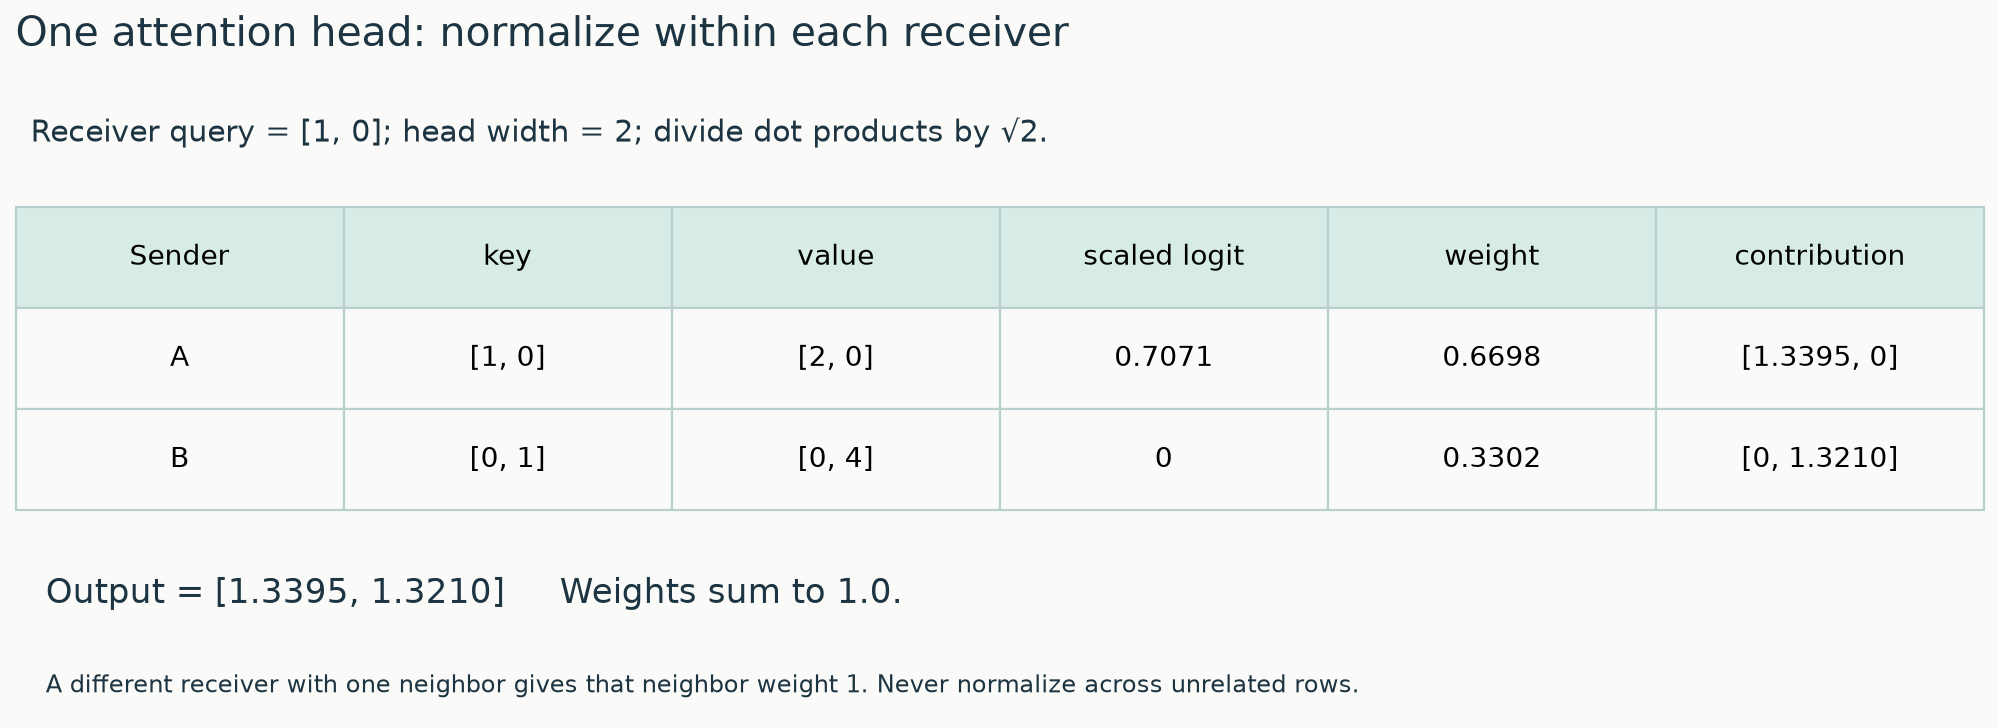</div><figcaption>Illustrative projected query/key/value fixture. Weights and contributions are calculated, then rounded to four decimals. A second receiver has a separate denominator. On narrow screens, scroll horizontally.</figcaption></figure>

A global softmax over every edge in a batch would let another row change these weights. The notebook CHECK includes a second receiver with only one neighbor; that neighbor must receive weight 1 regardless of the first receiver's scores. This is a useful failure test because a plausible-looking implementation can normalize over the wrong dimension.

> **Source audit.** We use the sender vector, as the released model does in `x[edge_index[1]]`. The paper's printed key/value equations use an `i` subscript; its accompanying discussion describes neighbors. The implementation and our index-role definition remove that ambiguity. Copied-weight output parity checks the whole local encoder, not just a hand-calculated softmax.



## 4. What transfers when columns change?

The model shares the transformations applied to every node, edge and message. It can process two cells today and eleven tomorrow without allocating eleven new feature-specific weight matrices. Column order also disappears from the representation: permuting whole leaf-edge pairs permutes intermediate leaf states while leaving the center readout unchanged, up to floating-point rounding.

**Preserve the pairing.** Permuting values while leaving edge labels fixed changes the facts represented by the row. That transformation should generally change the prediction. Reordering pairs and scrambling their alignment are different experiments.

**Names still carry assumptions.** Two meaningful column descriptions may have useful neighboring language representations. Two arbitrary codes may not. Renaming `ABV` to `column_7` preserves its numeric values but changes the relation vector. The model needs no explicit matching table to run, yet its predictions can depend strongly on the quality of names and embeddings.

**Units still matter.** A numerical transform fitted separately on each training table removes some scale differences. It does not guarantee that centimeters, kilograms and currencies become semantically interchangeable. Type handling, target meaning and deployment distribution remain part of the prediction contract.

### Three distinct transfer questions

| Setting | Source of reusable information | Target supervision | What our lab runs |
|---|---|---|---|
| Background pretraining → target | Released YAGO weights and FastText vectors | Small target train and validation sets | Yes, on three schemas |
| Labeled source table + target | Joint supervised fitting of related outcomes | Labels from both sources | Discussed, not run |
| Multiple source tables + target | Pairwise learners and their validation-weighted combination | Labels and target validation | Discussed, not run |

For supervised source-table transfer, compatible output meaning is essential. A common input representation alone cannot make two unrelated labels interchangeable. The paper's pairwise recipe mixes source and target rows during fine-tuning, monitors target validation, and combines pairwise and target-only learners using validation-based weights. Outcome transformations and source choice are part of that recipe. See [Section 3.3](https://arxiv.org/html/2402.16785v2#S3.SS3).

The wine targets supplied with the released examples already contain transformed prices, and the transformations differ across sources. Our experiment preserves each source's released target and evaluates it separately. It does not pool those targets into one supervised regression problem. This is why you must inspect target units before attempting the next transfer setting.



## 5. A controlled experiment with real target tables

### State the prediction before reading the measurements



The lab uses three real released tables: Wine Poland, Wine.com prices and Vivino prices. The column sets differ. Each table contributes 384 rows sampled without looking at target values after removing exact repeated entity names within that source. Sixty-four rows train the target predictor, 64 select its hyperparameters or epoch, and 256 score it. The split is repeated with three fixed seeds. Each arm receives identical rows for a given seed.

The full FastText binary is large. We extracted real 300-dimensional sentence vectors for the union of required strings into a compact portable cache. Computing a fixed pretrained vector for a held-out string does not fit on held-out labels or learn vocabulary statistics. The manifest records the binary hash, source row IDs, checkpoint hash and cache identity. Unknown strings outside this teaching cache require running the real string encoder; no zero or random replacement is supplied.

The source checkpoint and text model may have seen related public entities during their original training. That possible background overlap is not audited here. Exact name deduplication within these tables also does not resolve all real-world aliases. We test held-out sampled rows, not a guarantee of novel real-world entities or future vintages.

### Know what each arm answers

| Arm | Fitted components | Question |
|---|---|---|
| FastText center + ridge | Train-fitted feature scaling and ridge | How useful are language-conditioned inputs alone? |
| Random encoder + ridge | Same probe; encoder stays random | What comes from architecture and a probe alone? |
| Pretrained encoder + ridge | Same probe; encoder stays pretrained | Do transferred graph weights help fixed embeddings? |
| Scratch encoder + head | Encoder and linear head | What can this architecture learn from target labels? |
| Pretrained encoder + head | Encoder and linear head | Does pretrained initialization help matched target training? |
| CatBoost | Fixed 150-tree recipe on native columns | Is a practical tabular baseline competitive? |

Numerical transforms fit on target training rows only. A column constant among its observed training values uses standard scaling instead of a fitted power transform. A column entirely missing in training is omitted everywhere for that split. This fallback was added after a constant-volume split produced a power exponent near 35 and float32 overflow; the final experiment reruns every arm under the same rule. Ridge selects among `α = 1, 10, 100` on validation error; α controls the penalty on large coefficients. Fine-tuning and scratch use the same AdamW optimizer, learning rate `10⁻⁴`, weight decay `10⁻³`, 40 epochs, zero dropout and paired target-head initialization. Validation chooses the saved epoch. AdamW is a gradient-based update rule with adaptive coordinate step sizes and a separate weight-decay shrinkage term. An epoch is one pass through the labeled training rows; our small neural run uses all of them in one batch. Zero dropout means no hidden coordinates are randomly suppressed during these runs. Before neural training, target values are centered and scaled using the training target mean and standard deviation; predictions are converted back before scoring. Test scores never choose among these options. The tree recipe is fixed before evaluation.

The main metric is **R²**, `1 − Σ(y − prediction)² / Σ(y − mean_test(y))²`. A perfect prediction scores 1. A negative score means greater squared error than using the held-out target mean as a constant oracle comparator. That denominator is part of the metric, not a predictor fitted on test labels. Comparisons within a dataset share the same test rows and denominator.

**Author-reference R², mean ± sample SD across three seeds.** These saved values are separate from your fresh notebook run.

| Method | Wine Poland | Wine.com | Vivino |
|---|---|---|---|
| fasttext_ridge | -11.361 ± 19.166 | 0.328 ± 0.164 | 0.528 ± 0.028 |
| random_probe | -0.056 ± 0.288 | 0.328 ± 0.034 | 0.397 ± 0.099 |
| scratch | 0.261 ± 0.150 | 0.408 ± 0.025 | 0.541 ± 0.018 |
| pretrained_probe | 0.162 ± 0.079 | -0.072 ± 0.167 | 0.262 ± 0.024 |
| pretrained_ft | 0.047 ± 0.028 | 0.270 ± 0.198 | 0.476 ± 0.051 |
| catboost | 0.134 ± 0.034 | 0.278 ± 0.035 | 0.446 ± 0.013 |

**Observed pattern.** Pretrained fine-tuning has higher mean R² than scratch on 0 of 3 targets. The frozen pretrained probe exceeds the frozen random probe on 1 of 3. These comparisons isolate different adaptation settings; neither count establishes broad superiority.

**Paired fine-tuned pretrained minus scratch gains:**

- wine_pl: -0.259, -0.317, -0.067; mean -0.215, descriptive t95 [-0.539, +0.110].
- wine_dot_com_prices: -0.359, -0.039, -0.015; mean -0.138, descriptive t95 [-0.615, +0.340].
- wine_vivino_price: -0.026, -0.079, -0.090; mean -0.065, descriptive t95 [-0.150, +0.020].

**Exploratory dataset-balanced mean ranks** (lower is better): fasttext_ridge 3.67, random_probe 4.00, scratch 1.00, pretrained_probe 4.67, pretrained_ft 4.00, catboost 3.67. Friedman p=0.221; Nemenyi critical difference=4.35. Only three related datasets contribute.


<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable results figure">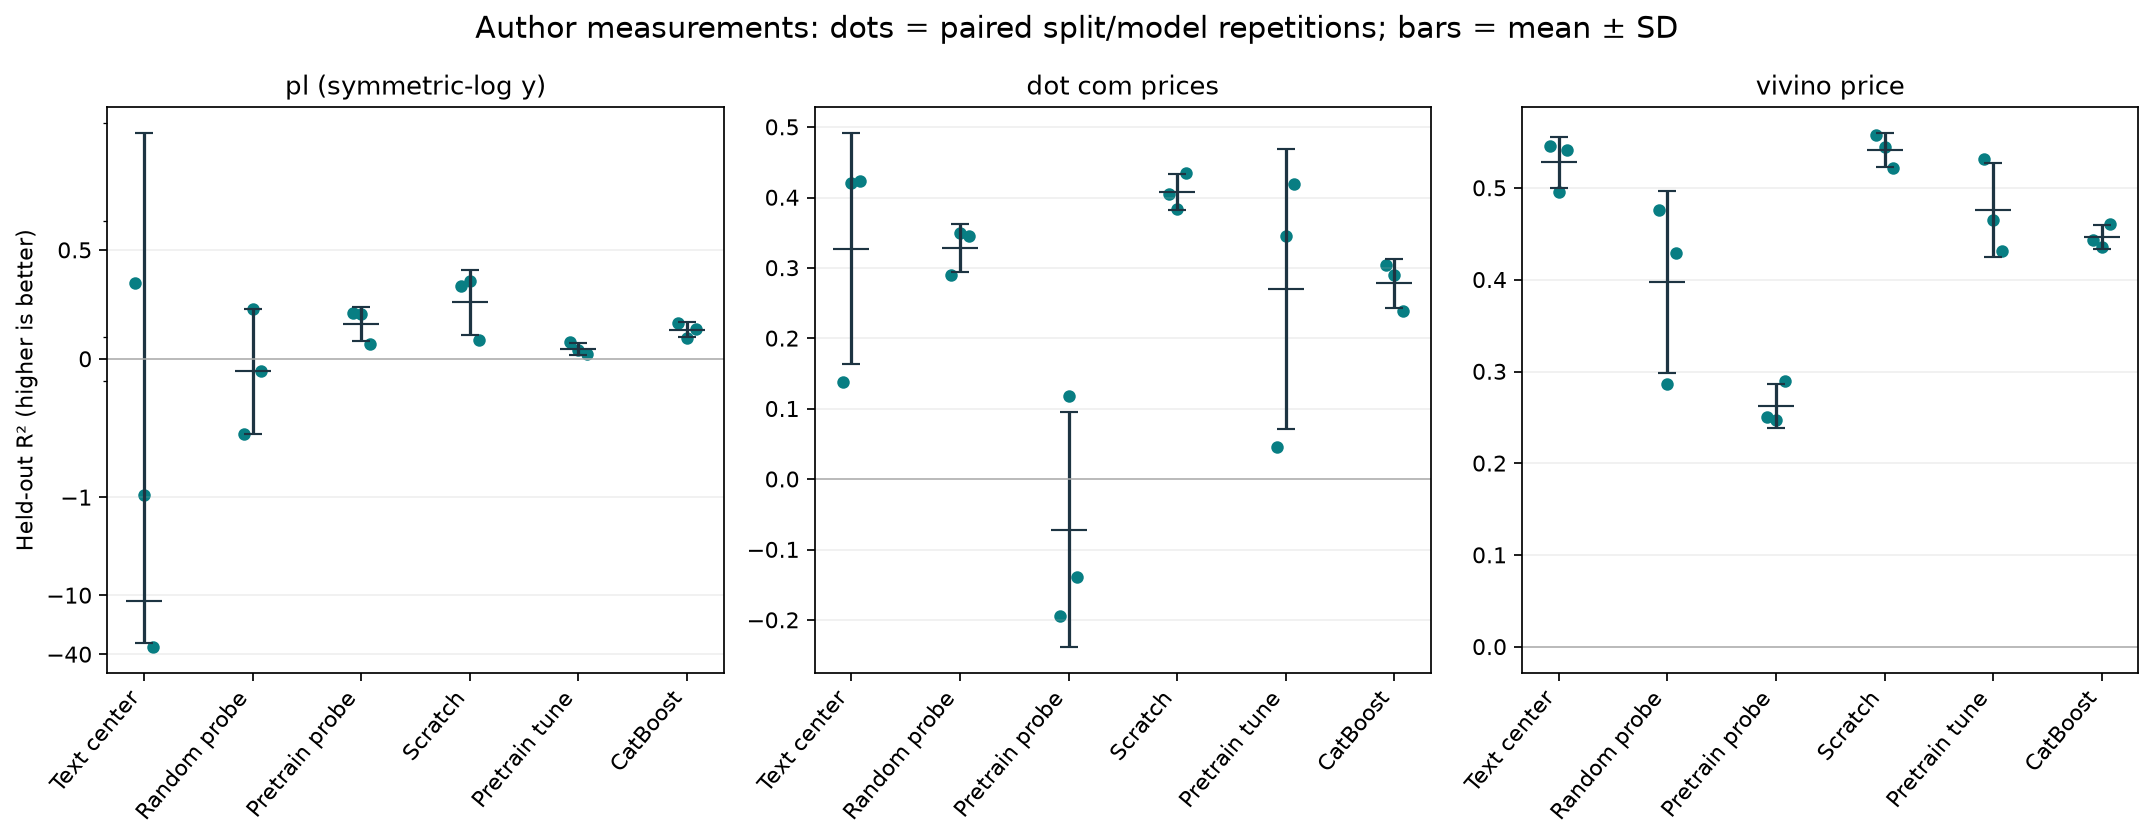</div><figcaption>Author-reference measurements, three paired split/model repetitions per table. Dots show each run; bars show mean plus or minus sample SD. Poland uses a symmetric-log vertical scale (linear within ±0.5) to keep the large negative baseline score visible; the other panels are linear. These related wine datasets do not establish general cross-domain superiority. On narrow screens, scroll horizontally.</figcaption></figure>

Read the per-seed points before the means. For the main initialization contrast, subtract scratch R² from fine-tuned pretrained R² within each seed. Averaging unpaired scores first hides whether a difficult split affected both arms. The notebook stores predictions so you can recompute each metric independently.

> **Scope check.** These three datasets share a wine domain. Three overlapping split repetitions measure sensitivity within these datasets; they are not three independent new populations. The displayed standard deviations describe repetitions. The exploratory Friedman and Nemenyi calculations use one mean rank per dataset, not one dataset per seed. With only three related datasets and six methods, they support very limited inference.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable audit figure">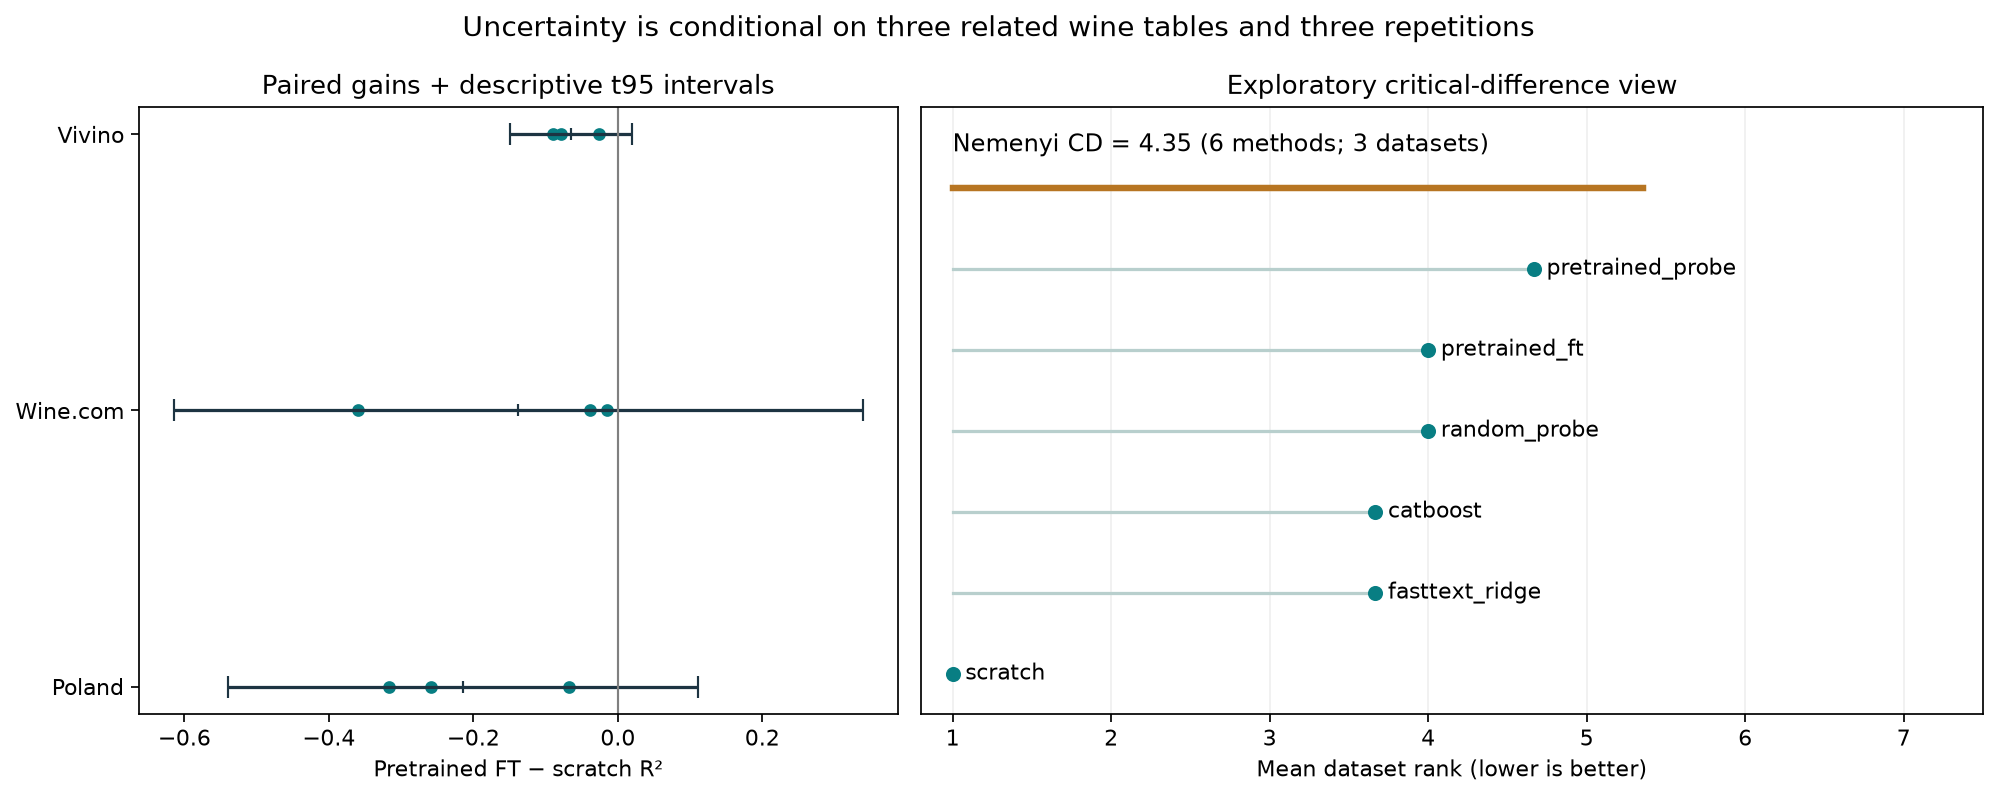</div><figcaption>Paired initialization gains with descriptive t95 intervals over three repetitions; separate dataset-balanced rank/CD view. Repeated splits overlap and the datasets share a domain. These are exploratory summaries, not broad population intervals. On narrow screens, scroll horizontally.</figcaption></figure>

A **rank** is a method’s position within one dataset, with rank 1 assigned to the highest mean R² and ties receiving averaged positions. The **Friedman test** evaluates whether methods have systematically different within-dataset ranks. Its p-value measures how unusual the observed rank differences would be under the test’s equal-performance null model. The **Nemenyi comparison** uses a critical difference: a threshold for a pair’s mean-rank separation that accounts for comparing multiple methods.

The paired interval uses `mean gain ± 4.303 × sample SD / √3`, with the Student-t multiplier for two degrees of freedom. Its assumptions are imperfect because repeated splits overlap. The critical difference is the Nemenyi threshold on average ranks under its dataset-level assumptions; it is larger than many plausible rank gaps with this small collection. Treat both as descriptive checks on the strength of the evidence.

### What this run found

Pretrained fine-tuning has a lower mean R² than scratch on all three targets in this particular single-readout, linear-head recipe. Frozen pretrained embeddings improve over random embeddings on Wine Poland and trail them on Wine.com and Vivino. The initialization and frozen-representation questions therefore have different answers even within these related sources.

The raw language-conditioned ridge baseline has a large negative Wine Poland score in one repetition. The numerical fix guarantees finite inputs; it does not guarantee useful extrapolation beyond a constant training feature. The result table preserves that error. The Poland plot uses a symmetric-log vertical scale, linear near zero and compressed for large magnitudes, so both the failed run and the neural scores remain visible. Other panels use ordinary linear scales. This is a diagnostic observation, not a causal attribution to one column; establishing the cause would require a separately declared feature intervention.

The selected downstream depth, strict input-map transfer, head, training budget and lack of bagging all differ from the paper's full evaluation recipe. This local result is a reason to audit those choices in a follow-up; it cannot establish that published CARTE transfer gains are false.

### Diagnose a gain or a failure

If frozen transfer helps but fine-tuning loses, inspect the selected epoch and optimization sensitivity. If both random and pretrained probes help similarly, the architecture or input language vectors may explain much of the gain. If a tree wins, preserve that result and ask which information or sample-size advantage the encoder has yet to demonstrate.

Pretraining consumes substantial historical compute even when a checkpoint is cheap to download. Target fitting receives 128 development labels in this experiment, including validation. A statement such as “64-label learning” must retain that validation cost. Model-selection effort and pretraining resources are different accounting dimensions.



## 6. Lab: implement, check, then interpret

Open the notebook using the links at the top. Its explanations and portable figures travel with it.

1. **TODO — construct a row graph.** Omit missing cells, encode values according to type, build receiver/sender indices, and compute the release-specific center. CHECK the worked fixture and the all-missing policy.
2. **TODO — group attention by receiver.** Implement a numerically stable grouped softmax and weighted sum. CHECK the two-receiver example and extreme logits.
3. **TODO — select a probe honestly.** Fit scaling on training embeddings, choose the ridge penalty on validation labels, and predict the untouched test embeddings. CHECK that changing held-out inputs cannot alter predictions for another held-out row.
4. **RUN — transfer against scratch.** The visible encoder and trainer call your functions. Generate fresh scores and paired gains; compare your results to the clearly labeled author reference.
5. **EXIT — explain one failed prediction.** Submit the three tables, paired initialization gains and a 150–250-word explanation. Identify the exact source of transferred information, count development labels, state one unresolved alternative explanation, and propose a controlled follow-up.

The required post-EXIT extension increases target training rows from 64 to 128 and training length from 40 to 100 epochs while retaining the same implementation. It is a closer local sensitivity check, gated off by default. It remains far from original YAGO pretraining, original splits, full downstream ensembles and the published benchmark. The [reproduction contract](../labs/l074-reproduction.md) states what was actually run.



## 7. The bridge to relational learning

A CARTE row graph organizes relationships *inside one record*. Its node and edge labels supply context for each cell. At target inference, our graph for a wine contains no link to another row's producer record, transactions or future events.

A relational database graph can additionally connect distinct records through entity relationships such as foreign keys. Those links introduce a new information-access question: which neighboring records existed and were observable at prediction time? Good within-row transfer does not settle that temporal question.

CARTE contributes a way to encode semantically described values across schemas. The next planned unit, **Lesson 75: PyTorch Frame**, makes mixed-type row encoding an explicit reusable component. Later graph models can place such row representations on a graph of related records. Keep the two levels clear: encode a record's contents, then propagate permitted information between records.

**Tomorrow, without notes:** draw a text leaf and a numerical leaf; reconstruct the grouped attention denominator; explain why schema acceptance is weaker than evidence of useful transfer. In a week, repeat the explanation with a source table whose target uses different units.



## Sources and evidence boundaries

- [CARTE paper v2](https://arxiv.org/html/2402.16785v2): primary reading for representation, background pretraining and supervised transfer recipes.
- [Pinned model implementation](https://github.com/soda-inria/carte/blob/f54690da4cddbedd1e1a9113a312f85783d2c125/carte_ai/src/carte_model.py) and [converter](https://github.com/soda-inria/carte/blob/f54690da4cddbedd1e1a9113a312f85783d2c125/carte_ai/src/carte_table_to_graph.py): executable conventions and the source discrepancies explained above.
- [Pinned estimator](https://github.com/soda-inria/carte/blob/f54690da4cddbedd1e1a9113a312f85783d2c125/carte_ai/src/carte_estimator.py): downstream depth and weight-loading behavior.
- [Local provenance](../labs/_sources_l074.json), [measured evidence](../labs/_verify_l074_results.json), and [contract](../labs/l074-reproduction.md): identities, predictions and deviations.

**Verified locally:** see the measured evidence and delivery report. **Paper claim:** cross-schema pretraining and supervised transfer benefits under the authors' experiments. **Original benchmark reproduction:** INCOMPARABLE. **New YAGO pretraining and source-table joint learning:** NOT_RUN. Browser, live Colab and deployment each have separate verification status.



## Paper reproduction track

The [paper reproduction section](../labs/html/0074-carte-cross-table-transfer.html#paper-reproduction) in the companion notebook includes the full runnable paper/release implementation after EXIT, separately from its compact teaching experiment. Read the [reproduction guide](../labs/reproductions/README.md) for the named target, full-data commands, source pins and remaining gaps. The full model and training code are visible in the notebook. Smoke execution and source equivalence are checks; published-result reproduction requires the aligned experiment and its measured comparison.


<a id="lab-exercises"></a>
## Implement and measure

The real string cache and selected pretrained parameters are provided under `data/l074`. No full FastText installation is required for the default lab. The source audit uses an optional PyG dependency outside this notebook. Run from the course `labs/` directory; the bootstrap does this on Colab. Local CPU execution takes several minutes.

In [ ]:
import copy
import hashlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import PowerTransformer,StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import rankdata,friedmanchisquare,studentized_range
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
torch.set_num_threads(1)
assert Path("data/l074/manifest.json").exists(), "Run this notebook from the course labs directory"
manifest=json.loads(Path("data/l074/manifest.json").read_text())
for name,digest in manifest["files"].items():
    assert hashlib.sha256((Path("data/l074")/name).read_bytes()).hexdigest()==digest
print("Data, vector and checkpoint hashes verified")

### TODO · make_graph

**Goal.** Build the release-specific row graph from a mapping of column names to values and a fixed string-vector dictionary. Return node features, receiver/sender indices and edge attributes. Omit missing cells; reject an all-missing row. Preserve value-column pairing.

**Why it matters.** This function controls the representation or the evidence boundary of the actual run below.

**Hint boundary.** Return the documented shapes and preserve the training/validation/test roles. Predict the CHECK result before running it.

In [ ]:
def make_graph(row, vectors):
    raise NotImplementedError("make_graph")

In [ ]:
# CHECK
vec={'a':np.array([1.,2.]),'b':np.array([3.,1.]),'red':np.array([2.,-1.])}
g=make_graph({'a':'red','b':2.,'missing':None},vec)
assert torch.allclose(g[0][0],torch.tensor([10.,0.]))
assert torch.equal(g[1],torch.tensor([[0,0,1,2],[1,2,1,2]]))
assert torch.equal(g[2][-2:],torch.ones(2,2))
try:make_graph({'a':None},vec)
except ValueError:pass
else:raise AssertionError('Reject an undefined all-missing center')
print("make_graph: passed")

### TODO · grouped_attention

**Goal.** Compute scaled dot-product attention and weighted outputs, normalizing independently for each receiver. Use a stable softmax. Return the output tensor and one weight per edge. The result must remain differentiable.

**Why it matters.** This function controls the representation or the evidence boundary of the actual run below.

**Hint boundary.** Return the documented shapes and preserve the training/validation/test roles. Predict the CHECK result before running it.

In [ ]:
def grouped_attention(edge_index, query, key, value):
    raise NotImplementedError("grouped_attention")

In [ ]:
# CHECK
ei=torch.tensor([[0,0,1],[0,1,0]])
q=torch.tensor([[1.,0.],[0.,1.]],requires_grad=True)
k=torch.tensor([[1.,0.],[0.,1.],[3.,2.]])
v=torch.tensor([[2.,0.],[0.,4.],[7.,8.]])
o,a=grouped_attention(ei,q,k,v)
assert torch.allclose(a[:2],torch.tensor([.6697615,.3302385]),atol=1e-6)
assert a[2]==1 and torch.equal(o[1],v[2])
o.sum().backward();assert q.grad is not None and torch.isfinite(q.grad).all()
o,a=grouped_attention(ei,q.detach()*10000,k,v)
assert torch.isfinite(o).all() and torch.isfinite(a).all()
print("grouped_attention: passed")

### TODO · ridge_predict

**Goal.** Fit StandardScaler on training embeddings only. Try Ridge penalties 1, 10 and 100. Choose the smallest validation MSE (first candidate on a tie), and return test predictions plus the selected penalty. Do not refit using validation or test rows.

**Why it matters.** This function controls the representation or the evidence boundary of the actual run below.

**Hint boundary.** Return the documented shapes and preserve the training/validation/test roles. Predict the CHECK result before running it.

In [ ]:
def ridge_predict(train,valid,test,ytrain,yvalid):
    raise NotImplementedError("ridge_predict")

In [ ]:
# CHECK
x=np.arange(18,dtype=float).reshape(9,2);y=np.arange(9,dtype=float)
p,alpha=ridge_predict(x[:5],x[5:7],x[7:],y[:5],y[5:7])
changed=x[7:].copy();changed[1]=1e9
p2,alpha2=ridge_predict(x[:5],x[5:7],changed,y[:5],y[5:7])
assert alpha in [1.,10.,100.] and alpha==alpha2
assert np.allclose(p[0],p2[0]),'Test features must not fit the scaler'
assert p.shape==(2,)
print("ridge_predict: passed")

### PROVIDED · Model architecture: column-conditioned attention, normalization and center readout

Trace the exact tensors and label access through these visible definitions. Each TODO remains bound in this notebook kernel; no hidden model import replaces it.

In [ ]:
class Attention(nn.Module):
    def __init__(self,d=300,heads=12):
        super().__init__();self.heads=heads
        self.lin_query=nn.Linear(d,d,bias=False)
        self.lin_key=nn.Linear(d,d,bias=False)
        self.lin_value=nn.Linear(d,d,bias=False)
    def forward(self,x,index,edge):
        z=edge*x[index[1]]
        q,k,v=self.lin_query(x),self.lin_key(z),self.lin_value(z)
        width=q.shape[1]//self.heads
        return torch.cat([grouped_attention(index,q[:,i:i+width],k[:,i:i+width],v[:,i:i+width])[0] for i in range(0,q.shape[1],width)],1)

In [ ]:
class Readout(nn.Module):
    def __init__(self):
        super().__init__();self.g_attn=Attention()
        self.linear_net_x=nn.Sequential(nn.Linear(300,300),nn.Dropout(0),nn.GELU(),nn.Linear(300,300))
        self.norm1_x=nn.LayerNorm(300);self.norm2_x=nn.LayerNorm(300)
    def forward(self,x,index,edge):
        # The pinned code has no node residual addition in this block.
        x=self.norm1_x(self.g_attn(x,index,edge))
        return self.norm2_x(self.linear_net_x(x))

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.initial_x=nn.Sequential(nn.Linear(300,300),nn.GELU(),nn.LayerNorm(300))
        self.initial_e=nn.Sequential(nn.Linear(300,300),nn.GELU(),nn.LayerNorm(300))
        self.read_out_block=Readout()
    def forward(self,x,index,edge):
        return self.read_out_block(self.initial_x(x),index,self.initial_e(edge))
    def rows(self,x,index,edge,heads):
        # Only center outputs are consumed. Leaf inputs still supply keys/values.
        receiver_map=torch.full((len(x),),-1,dtype=torch.long)
        receiver_map[heads]=torch.arange(len(heads))
        keep=receiver_map[index[0]]>=0
        row_ids=receiver_map[index[0,keep]]
        x=self.initial_x(x);edge=self.initial_e(edge[keep])
        attn=self.read_out_block.g_attn
        z=edge*x[index[1,keep]]
        q,k,v=attn.lin_query(x[heads]),attn.lin_key(z),attn.lin_value(z)
        row_index=torch.stack([row_ids,torch.zeros_like(row_ids)])
        width=q.shape[1]//attn.heads
        output=torch.cat([grouped_attention(row_index,q[:,i:i+width],k[:,i:i+width],v[:,i:i+width])[0] for i in range(0,q.shape[1],width)],1)
        output=self.read_out_block.norm1_x(output)
        return self.read_out_block.norm2_x(self.read_out_block.linear_net_x(output))

### PROVIDED · Strict checkpoint loading and disconnected graph batches

Trace the exact tensors and label access through these visible definitions. Each TODO remains bound in this notebook kernel; no hidden model import replaces it.

In [ ]:
def load_encoder(checkpoint,pretrained,seed):
    torch.manual_seed(seed);model=Encoder()
    if pretrained:
        state=torch.load(checkpoint,map_location='cpu',weights_only=True)
        selected={k:state['ft_base.'+k] for k in model.state_dict()}
        model.load_state_dict(selected,strict=True)
    return model

In [ ]:
def batch_graphs(graphs):
    xs,es,attrs,heads=[],[],[],[];offset=0
    for x,index,edge in graphs:
        heads.append(offset);xs.append(x);es.append(index+offset);attrs.append(edge);offset+=len(x)
    return torch.cat(xs),torch.cat(es,1),torch.cat(attrs),torch.tensor(heads)

In [ ]:
def embed(model,graphs):
    model.eval();parts=[]
    with torch.no_grad():
        for i in range(0,len(graphs),64):
            x,index,edge,heads=batch_graphs(graphs[i:i+64]);parts.append(model.rows(x,index,edge,heads).numpy())
    return np.concatenate(parts)

### PROVIDED · Matched target training and validation checkpoint selection

Trace the exact tensors and label access through these visible definitions. Each TODO remains bound in this notebook kernel; no hidden model import replaces it.

In [ ]:
def tune(model,graphs,y,train,valid,test,epochs,seed):
    torch.manual_seed(seed+900)
    head=nn.Linear(300,1);optimizer=torch.optim.AdamW(list(model.parameters())+list(head.parameters()),lr=1e-4,weight_decay=1e-3)
    mean=float(y[train].mean());scale=float(y[train].std());target=torch.tensor((y-mean)/scale,dtype=torch.float32)
    tensors=[batch_graphs([graphs[i] for i in ids]) for ids in [train,valid,test]]
    best=None
    for epoch in range(epochs):
        model.train();head.train();x,index,edge,h=tensors[0]
        loss=((head(model.rows(x,index,edge,h)).flatten()-target[train])**2).mean()
        optimizer.zero_grad();loss.backward();optimizer.step()
        model.eval();head.eval()
        with torch.no_grad():
            x,index,edge,h=tensors[1];vl=float(((head(model.rows(x,index,edge,h)).flatten()-target[valid])**2).mean())
        if best is None or vl<best[0]:best=(vl,copy.deepcopy(model.state_dict()),copy.deepcopy(head.state_dict()),epoch+1)
    model.load_state_dict(best[1]);head.load_state_dict(best[2])
    with torch.no_grad():
        x,index,edge,h=tensors[2];prediction=head(model.rows(x,index,edge,h)).flatten().numpy()*scale+mean
    return prediction,best[3]

### PROVIDED · Same target IDs, multiple controls, saved predictions and dataset-balanced ranks

Trace the exact tensors and label access through these visible definitions. Each TODO remains bound in this notebook kernel; no hidden model import replaces it.

In [ ]:
def normalize_numeric(frame,train):
    """Fit per-column maps using train only; constant columns need no power fit."""
    out=frame.copy();policy={}
    for col in frame.select_dtypes(include='number'):
        observed=frame.iloc[train][col].dropna()
        if len(observed)==0:
            out[col]=np.nan;policy[col]='unobserved_train_omit';continue
        constant=observed.nunique()==1
        transformer=StandardScaler() if constant else PowerTransformer()
        transformer.fit(frame.iloc[train][[col]])
        out[col]=transformer.transform(frame[[col]]).flatten()
        policy[col]='standard_constant' if constant else 'power'
    return out,policy

In [ ]:
def run_transfer(data_dir='data/l074',seeds=(0,1,2),epochs=40,train_size=64):
    torch.set_num_threads(1);root=Path(data_dir)
    manifest=json.loads((root/'manifest.json').read_text())
    payload=np.load(root/'vectors.npz');vectors=dict(zip(payload['names'].tolist(),payload['vectors']))
    records=[];splits=[]
    for dataset in manifest['datasets']:
        frame=pd.read_parquet(root/(dataset+'.parquet'));target=manifest['datasets'][dataset]['target']
        y=frame.pop(target).to_numpy(dtype=float);numeric=frame.select_dtypes(include='number').columns.tolist()
        for seed in seeds:
            ids=np.random.default_rng(seed+74).permutation(len(frame));tr=ids[:train_size];va=ids[train_size:train_size+64];te=ids[train_size+64:]
            if len(te)<32:raise ValueError('Need at least 32 test rows')
            X,numeric_policy=normalize_numeric(frame,tr)
            graphs=[make_graph(row,vectors) for row in X.to_dict('records')]
            splits.append({'dataset':dataset,'seed':seed,'train':tr.tolist(),'validation':va.tolist(),'test':te.tolist(),'numeric_policy':numeric_policy})
            raw=np.stack([g[0][0].numpy() for g in graphs]);arms={}
            arms['fasttext_ridge']=ridge_predict(raw[tr],raw[va],raw[te],y[tr],y[va])
            for pre,name in [(False,'random'),(True,'pretrained')]:
                model=load_encoder(root/'kg_pretrained.pt',pre,seed)
                features=embed(model,graphs)
                arms[name+'_probe']=ridge_predict(features[tr],features[va],features[te],y[tr],y[va])
                arms['scratch' if not pre else 'pretrained_ft']=tune(model,graphs,y,tr,va,te,epochs,seed)
            cats=[c for c in frame if c not in numeric];treeX=frame.copy()
            for c in cats:treeX[c]=treeX[c].fillna('<missing>').astype(str)
            for c in numeric:treeX[c]=treeX[c].fillna(float(treeX.iloc[tr][c].median()))
            tree=CatBoostRegressor(iterations=150,depth=4,learning_rate=.05,loss_function='RMSE',random_seed=seed,thread_count=1,verbose=False,allow_writing_files=False)
            tree.fit(treeX.iloc[tr],y[tr],cat_features=cats)
            arms['catboost']=(tree.predict(treeX.iloc[te]),150)
            for arm,(pred,selected) in arms.items():
                records.append({'dataset':dataset,'seed':seed,'arm':arm,'r2':float(r2_score(y[te],pred)),'selected':float(selected),'prediction':np.asarray(pred).tolist(),'target':y[te].tolist()})
            print(dataset,seed,'done',flush=True)
    names=list(arms);summary=[];ranks=[]
    for dataset in manifest['datasets']:
        means=[]
        for arm in names:
            vals=[r['r2'] for r in records if r['dataset']==dataset and r['arm']==arm];means.append(np.mean(vals))
            summary.append({'dataset':dataset,'arm':arm,'mean':float(np.mean(vals)),'sd':float(np.std(vals,ddof=1)) if len(vals)>1 else 0.})
        ranks.append(rankdata(-np.array(means)))
    stat,p=friedmanchisquare(*np.array(ranks).T)
    return {'config':{'seeds':list(seeds),'epochs':epochs,'train_size':train_size,'validation_size':64,'datasets':list(manifest['datasets']),'arms':names},'records':records,'splits':splits,'summary':summary,'ranks':{'mean':dict(zip(names,np.array(ranks).mean(0).tolist())),'friedman_p':float(p),'nemenyi_cd':float(studentized_range.ppf(.95,len(names),np.inf)/np.sqrt(2)*np.sqrt(len(names)*(len(names)+1)/(6*len(ranks))))},'benchmark_verdict':'INCOMPARABLE'}

### RUN · commit predictions

Write the sign you expect for pretrained fine-tuning minus scratch on each table. State which comparison isolates graph pretraining beyond the text vectors.

In [ ]:
assert run_transfer.__globals__['make_graph'] is make_graph
assert Attention.forward.__globals__['grouped_attention'] is grouped_attention
assert run_transfer.__globals__['ridge_predict'] is ridge_predict
result=run_transfer()
Path('l074-student-results.json').write_text(json.dumps(result,indent=2))
display(pd.DataFrame(result['summary']).pivot(index='arm',columns='dataset',values='mean'))

In [ ]:
# Fresh paired gains: join seed identities before subtracting
frame=pd.DataFrame(result['records'])
pair=frame.pivot(index=['dataset','seed'],columns='arm',values='r2')
pair['gain']=pair['pretrained_ft']-pair['scratch']
display(pair[['pretrained_ft','scratch','gain']])
fig,ax=plt.subplots(figsize=(8,4))
for i,d in enumerate(result['config']['datasets']):
    vals=pair.loc[d,'gain'];ax.scatter([i]*len(vals),vals);ax.plot(i,vals.mean(),'k_',markersize=18)
ax.axhline(0,color='gray');ax.set_xticks(range(3),result['config']['datasets'],rotation=15);ax.set_ylabel('Pretrained FT − scratch R²');plt.tight_layout();plt.show()

### EXIT · submit the evidence and explanation

Submit the mean/SD table, per-seed paired gains and a 150–250-word explanation of one failed prediction. Name the pretraining source, input semantics, development-label cost, and one inference boundary. Describe a follow-up that changes exactly one intended factor. A loss for transfer is an admissible result.

In [ ]:
assert len(result['records'])==54
for s in result['splits']:
    tr,va,te=map(set,[s['train'],s['validation'],s['test']])
    assert len(tr)==64 and len(va)==64 and len(te)==256
    assert not tr&va and not tr&te and not va&te
for r in result['records']:
    assert abs(r2_score(r['target'],r['prediction'])-r['r2'])<1e-12
print('Structural EXIT passed. Written interpretation requires tutor review.')

**Write your interpretation here.** Return tomorrow and reconstruct the graph without the figure.

### Optional teaching extension · larger local run

Predeclare the 128-row target budget and 100 supervised epochs before running. This local extension uses the same graph/model functions, 64 validation rows and the remaining 192 test rows. It varies two resources together; use separate one-factor follow-ups to diagnose the cause of any difference. Its test population differs from the default, so do not interpret score changes as a pure training-budget effect. This is closer local training, still INCOMPARABLE to paper pretraining, joint transfer and bagged benchmarks. CPU is sufficient; no Modal dependency is needed.

In [ ]:
RUN_TEACHING_EXTENSION=False
if RUN_TEACHING_EXTENSION:
    larger=run_transfer(train_size=128,epochs=100)
    Path('l074-closer-results.json').write_text(json.dumps(larger,indent=2))
    print('Verified here: larger local target adaptation; paper benchmark: INCOMPARABLE')
else:
    print('Verified here: default local run; paper claim: cited; larger run: NOT_RUN; live Colab: NOT_CHECKED')

<a id="paper-reproduction"></a>
## Paper reproduction · implementation, protocol, and measured comparison

**Target:** released CARTE single-table benchmark rows for wina_pl, wine_dot_com_prices and wine_vivino_price; seven training budgets, ten outer splits, fifteen validation-split models per fit. The default uses the June 2024 paper-era source; the newer release is an explicit alternative in the repository operator. The source below includes the entire architecture, graph conversion, checkpoint loader, prediction head, training loop and ensemble. Published per-split learning rates and scores are joined by dataset/budget/seed.

The model uses the release's checkpoint-loading behavior, including its handling of initial_x, and its full 300→150→75→1 prediction head. The 384-row teaching cache cannot supply these full-table runs. A full FastText model and released checkpoint are required. Fresh YAGO pretraining, all other benchmark datasets, and joint source-table transfer remain separate reproduction targets; downstream replay does not establish them.

**Read → predict → run.** Compare each architecture and stopping rule below with the teaching lane. Predict which protocol changes could reverse its ranking. The following PROVIDED cells write the visible source to an isolated `paper-run` folder. The runner imports those exact files, so edits in these cells are the implementation it trains. Run all source cells before enabling the final run. After editing a source chunk, rerun that file’s source cells from the first chunk so append cells do not duplicate definitions. Preserve the pinned copy for parity checks.

**Evidence rule:** a smoke run tests execution and is always INCOMPARABLE. A full run records published targets, measured gaps, source choices and missing details; a small score gap alone does not certify protocol identity. [Reproduction guide](../labs/reproductions/README.md).

In [ ]:
# PROVIDED: isolated files for the visible paper implementation
from pathlib import Path
import sys, subprocess
PAPER_ROOT=Path('paper-run').resolve()
PAPER_ROOT.mkdir(exist_ok=True)

### PROVIDED · sources/carte_paper/configs/directory.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/carte_paper/configs').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/carte_paper/configs/directory.py
"""
Configurations for directory
"""

from pathlib import Path

base_path = Path().cwd()
config_directory = dict()
config_directory["base_path"] = base_path

config_directory["data"] = str(base_path / "data/")
config_directory["checkpoints"] = str(base_path / "data/ckpt/")
config_directory["pretrained_model"] = str(base_path / "data/etc/kg_pretrained.pt")
config_directory["data_raw"] = str(base_path / "data/data_raw/")
config_directory["data_singletable"] = str(base_path / "data/data_singletable/")
config_directory["data_ds_oov"] = str(base_path / "data/data_ds_oov/")
config_directory["data_multitable"] = str(base_path / "data/data_multitable/")
config_directory["data_ds_tabllm"] = str(base_path / "data/data_ds_tabllm/")
config_directory["data_yago"] = str(base_path / "data/data_yago/")
config_directory["etc"] = str(base_path / "data/etc/")

config_directory["results"] = str(base_path / "results/")
config_directory["visualization"] = str(base_path / "visualization/")

# Specify the directory in which you have downloaded each
config_directory["fasttext"] = str(base_path / "data/etc/cc.en.300.bin")
config_directory["infloat-v2"] = str(base_path / "data/etc/intfloat_e5-large-v2")
config_directory["ken_embedding"] = str(base_path / "data/etc/ken_embedding.parquet")




### PROVIDED · sources/carte_paper/src/carte_estimator.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/carte_paper/src').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/carte_paper/src/carte_estimator.py
"""CARTE estimators for regression and classification."""

import torch
import numpy as np
import pandas as pd
import copy
import math
from typing import Union
from torcheval.metrics import (
    MeanSquaredError,
    R2Score,
    BinaryAUROC,
    BinaryNormalizedEntropy,
    BinaryAUPRC,
    MulticlassAUROC,
)
from torch import Tensor
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch
from sklearn.model_selection import RepeatedKFold, RepeatedStratifiedKFold, ShuffleSplit, StratifiedShuffleSplit, ParameterGrid, train_test_split
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin
from sklearn.utils.validation import check_is_fitted, check_random_state
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.special import softmax
from src.carte_model import CARTE_NN_Model, CARTE_NN_Model_Ablation
from configs.directory import config_directory




#### BaseCARTEEstimator

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
class BaseCARTEEstimator(BaseEstimator):
    """Base class for CARTE Estimator."""



#### BaseCARTEEstimator.__init__

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def __init__(
        self,
        *,
        num_layers,
        load_pretrain,
        freeze_pretrain,
        learning_rate,
        batch_size,
        max_epoch,
        dropout,
        val_size,
        cross_validate,
        early_stopping_patience,
        num_model,
        random_state,
        n_jobs,
        device,
        disable_pbar,
    ):
        self.num_layers = num_layers
        self.load_pretrain = load_pretrain
        self.freeze_pretrain = freeze_pretrain
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.max_epoch = max_epoch
        self.dropout = dropout
        self.val_size = val_size
        self.cross_validate = cross_validate
        self.early_stopping_patience = early_stopping_patience
        self.num_model = num_model
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.device = device
        self.disable_pbar = disable_pbar



#### BaseCARTEEstimator.fit

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def fit(self, X, y):
        """Fit the CARTE model.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        y : array-like of shape (n_samples,)
            Target values.

        Returns
        -------
        self : object
               Fitted estimator.
        """
        # Preliminary settings
        self.is_fitted_ = False
        self.device_ = torch.device(self.device)
        self.X_ = X
        self.y_ = y
        self._set_task_specific_settings()

        # Set the cv-splits
        splits = self._set_train_valid_split()

        # Fit model
        result_fit = Parallel(n_jobs=self.n_jobs)(
            delayed(self._run_train_with_early_stopping)(X, split_index)
            for split_index in splits
        )

        # Store the required results that may be used later
        self.model_list_ = [model for (model, _) in result_fit]
        self.valid_loss_ = [valid_loss for (_, valid_loss) in result_fit]
        self.weights_ = np.array([1/self.num_model]*self.num_model)
        self.is_fitted_ = True

        return self



#### BaseCARTEEstimator._run_train_with_early_stopping

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _run_train_with_early_stopping(self, X, split_index):
        """Train each model corresponding to the random_state with the early_stopping patience.

        This mode of training sets train/valid set for the early stopping criterion.
        Returns the trained model, and the validation loss at the best epoch.
        """

        # Set datasets
        ds_train = [X[i] for i in split_index[0]]
        ds_valid = [X[i] for i in split_index[1]]

        # Set validation batch for evaluation
        ds_valid_eval = self._set_data_eval(data=ds_valid)

        # Load model and optimizer
        model_run_train = self._load_model()
        model_run_train.to(self.device_)
        optimizer = torch.optim.AdamW(
            model_run_train.parameters(), lr=self.learning_rate
        )

        # Train model
        train_loader = DataLoader(ds_train, batch_size=self.batch_size, shuffle=False)
        valid_loss_best = 9e15
        es_counter = 0
        model_best_ = copy.deepcopy(model_run_train)
        for _ in tqdm(
            range(1, self.max_epoch + 1),
            desc=f"Model No. xx",
            disable=self.disable_pbar,
        ):
            self._run_epoch(model_run_train, optimizer, train_loader)
            valid_loss = self._eval(model_run_train, ds_valid_eval)
            if valid_loss < valid_loss_best:
                valid_loss_best = valid_loss
                model_best_ = copy.deepcopy(model_run_train)
                es_counter = 0
            else:
                es_counter += 1
                if es_counter > self.early_stopping_patience:
                    break
        model_best_.eval()
        return model_best_, valid_loss_best



#### BaseCARTEEstimator._run_epoch

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _run_epoch(self, model, optimizer, train_loader):
        """Run an epoch of the input model.

        Each epoch consists of steps that update the model and the optimizer.
        """
        model.train()
        for data in train_loader:  # Iterate in batches over the training dataset.
            self._run_step(model, data, optimizer)



#### BaseCARTEEstimator._run_step

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _run_step(self, model, data, optimizer):
        """Run a step of the training.

        With each step, it updates the model and the optimizer.
        """
        optimizer.zero_grad()  # Clear gradients.
        data.to(self.device_)  # Send to device
        out = model(data)  # Perform a single forward pass.
        target = data.y  # Set target
        if self.output_dim_ == 1:
            out = out.view(-1).to(torch.float32)  # Reshape outputSet head index
            target = target.to(torch.float32)  # Reshape target
        loss = self.criterion_(out, target)  # Compute the loss.
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.



#### BaseCARTEEstimator._eval

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _eval(self, model, ds_eval):
        """Run an evaluation of the input data on the input model.

        Returns the selected loss of the input data from the input model.
        """
        with torch.no_grad():
            model.eval()
            out = model(ds_eval)
            target = ds_eval.y
            if self.output_dim_ == 1:
                out = out.view(-1).to(torch.float32)
                target = target.to(torch.float32)
            self.valid_loss_metric_.update(out, target)
            loss_eval = self.valid_loss_metric_.compute()
            loss_eval = loss_eval.detach().item()
            if self.valid_loss_flag_ == "neg":
                loss_eval = -1 * loss_eval
            self.valid_loss_metric_.reset()
        return loss_eval



#### BaseCARTEEstimator._set_train_valid_split

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _set_train_valid_split(self):
        """Train/validation split for the bagging strategy.
        
        The style of split depends on the cross_validate parameter.
        Reuturns the train/validation split with KFold cross-validation.
        """

        if self._estimator_type == "regressor":
            if self.cross_validate:
                n_splits = int(1 / self.val_size)
                n_repeats = int(self.num_model / n_splits)
                splitter = RepeatedKFold(
                    n_splits=n_splits, n_repeats=n_repeats, random_state=self.random_state,
                )
            else:
                splitter = ShuffleSplit(n_splits = self.num_model, test_size=self.val_size, random_state=self.random_state)
            splits = [
                    (train_index, test_index)
                    for train_index, test_index in splitter.split(np.arange(0, len(self.X_)))
                ]
        else:
            if self.cross_validate:
                n_splits = int(1 / self.val_size)
                n_repeats = int(self.num_model / n_splits)
                splitter = RepeatedStratifiedKFold(
                    n_splits=n_splits, n_repeats=n_repeats, random_state=self.random_state,
                )
            else:
                splitter = StratifiedShuffleSplit(n_splits = self.num_model, test_size=self.val_size, random_state=self.random_state)
            splits = [
                (train_index, test_index)
                for train_index, test_index in splitter.split(
                    np.arange(0, len(self.X_)), self.y_
                )
            ]

        return splits



#### BaseCARTEEstimator._set_data_eval

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _set_data_eval(self, data):
        """Constructs the aggregated graph object from the list of data.

        This is consistent with the graph object from torch_geometric.
        Returns the aggregated graph object.
        """
        make_batch = Batch()
        with torch.no_grad():
            ds_eval = make_batch.from_data_list(data, follow_batch=["edge_index"])
            ds_eval.to(self.device_)
        return ds_eval



#### BaseCARTEEstimator._generate_output

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _generate_output(self, X, model_list, weights):
        """Generate the output from the trained model.

        Returns the output (prediction) of input X.
        """

        # Obtain the batch to feed into the network
        ds_predict_eval = self._set_data_eval(data=X)
        with torch.no_grad():
            out = [
                model(ds_predict_eval).cpu().detach().numpy() for model in model_list
            ]
        out = np.array(out).squeeze().transpose()
        if len(model_list) != 1:
            out = np.average(out, weights=weights, axis=1)

        # Change if the task is classification
        if self.loss == "binary_crossentropy":
            out = 1 / (1 + np.exp(-out))
        elif self.loss == "categorical_crossentropy":
            out = softmax(out, axis=1)

        # Control for nulls in prediction
        if np.isnan(out).sum() > 0:
            mean_pred = np.mean(self.y_)
            out[np.isnan(out)] = mean_pred
        return out



#### BaseCARTEEstimator._set_task_specific_settings

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _set_task_specific_settings(self):
        """Set task specific settings for regression and classfication.
        """

        if self._estimator_type == "regressor":
            if self.loss == "squared_error":
                self.criterion_ = torch.nn.MSELoss()
            elif self.loss == "absolute_error":
                self.criterion_ = torch.nn.L1Loss()
            if self.scoring == "squared_error":
                self.valid_loss_metric_ = MeanSquaredError()
                self.valid_loss_flag_ = "pos"
            elif self.scoring == "r2_score":
                self.valid_loss_metric_ = R2Score()
                self.valid_loss_flag_ = "neg"
            self.output_dim_ = 1
        elif self._estimator_type == "classifier":
            if self.loss == "binary_crossentropy":
                self.criterion_ = torch.nn.BCEWithLogitsLoss()
            elif self.loss == "categorical_crossentropy":
                self.criterion_ = torch.nn.CrossEntropyLoss()
            self.output_dim_ = len(np.unique(self.y_))
            if self.output_dim_ == 2:
                self.output_dim_ -= 1
                self.criterion_ = torch.nn.BCEWithLogitsLoss()
            if self.scoring == "auroc":
                self.valid_loss_metric_ = BinaryAUROC()
                self.valid_loss_flag_ = "neg"
            elif self.scoring == "binary_entropy":
                self.valid_loss_metric_ = BinaryNormalizedEntropy(from_logits = True)
                self.valid_loss_flag_ = "neg"
            elif self.scoring == "auprc":
                self.valid_loss_metric_ = BinaryAUPRC()
                self.valid_loss_flag_ = "neg"
            if self.loss == "categorical_crossentropy":
                self.valid_loss_metric_ = MulticlassAUROC(num_classes=self.output_dim_)
                self.valid_loss_flag_ = "neg"
            self.classes_ = np.unique(self.y_)
        self.valid_loss_metric_.to(self.device_)



#### BaseCARTEEstimator._load_model

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _load_model(self):
        """Load the CARTE model for training.

        This loads the pretrained weights if the parameter load_pretrain is set to True.
        The freeze of the pretrained weights are controlled by the freeze_pretrain parameter.

        Returns the model that can be used for training.
        """
        # Model configuration
        model_config = dict()
        model_config["input_dim_x"] = self.X_[0].x.size(1)
        model_config["input_dim_e"] = self.X_[0].x.size(1)
        model_config["hidden_dim"] = self.X_[0].x.size(1)
        model_config["ff_dim"] = self.X_[0].x.size(1)
        model_config["num_heads"] = 12
        model_config["num_layers"] = self.num_layers-1
        model_config["output_dim"] = self.output_dim_
        model_config["dropout"] = self.dropout

        # Set seed for torch - for reproducibility
        random_state = check_random_state(self.random_state)
        model_seed = random_state.randint(10000)
        torch.manual_seed(model_seed)

        # Set model architecture
        model = CARTE_NN_Model(**model_config)

        # Load the pretrained weights if specified
        if self.load_pretrain:
            dir_model = config_directory["pretrained_model"]
            pretrain_model_dict = torch.load(dir_model, map_location=self.device_)
            initial_x_keys = [
                key for key in pretrain_model_dict.keys() if "initial_x" in key
            ]
            for key in initial_x_keys:
                pretrain_model_dict[key + "_pretrain"] = pretrain_model_dict.pop(key)
            model.load_state_dict(pretrain_model_dict, strict=False)

        # Freeze the pretrained weights if specified
        if self.freeze_pretrain:
            for param in model.ft_base.read_out_block.parameters():
                param.requires_grad = False
            for param in model.ft_base.layers.parameters():
                param.requires_grad = False

        return model




#### CARTERegressor

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
class CARTERegressor(RegressorMixin, BaseCARTEEstimator):
    """CARTE Regressor for Regression tasks.

    This estimator is GNN-based model compatible with the CARTE pretrained model.

    Parameters
    ----------
    loss : {'squared_error', 'absolute_error'}, default='squared_error'
        The loss function used for backpropagation.
    scoring : {'r2_score', 'squared_error'}, default='r2_score'
        The scoring function used for validation.
    num_layers : int, default=1
        The number of layers for the NN model
    load_pretrain : bool, default=True
        Indicates whether to load pretrained weights or not
    freeze_pretrain : bool, default=True
        Indicates whether to freeze the pretrained weights in the training or not
    learning_rate : float, default=1e-3
        The learning rate of the model. The model uses AdamW as the optimizer
    batch_size : int, default=16
        The batch size used for training
    max_epoch : int or None, default=500
        The maximum number of epoch for training
    dropout : float, default=0
        The dropout rate for training
    val_size : float, default=0.1
        The size of the validation set used for early stopping
    cross_validate : bool, default=False
        Indicates whether to use cross-validation strategy for train/validation split
    early_stopping_patience : int or None, default=40
        The early stopping patience when early stopping is used.
        If set to None, no early stopping is employed
    num_model : int, default=1
        The total number of models used for Bagging strategy
    random_state : int or None, default=0
        Pseudo-random number generator to control the train/validation data split
        if early stoppingis enabled, the weight initialization, and the dropout.
        Pass an int for reproducible output across multiple function calls.
    n_jobs : int, default=1
        Number of jobs to run in parallel. Training the estimator the score are parallelized
        over the number of models.
    device : {"cpu", "gpu"}, default="cpu",
        The device used for the estimator.
    disable_pbar : bool, default=True
        Indicates whether to show progress bars for the training process.
    """

    def __init__(
        self,
        *,
        loss: str = "squared_error",
        scoring: str = "r2_score",
        num_layers: int = 1,
        load_pretrain: bool = True,
        freeze_pretrain: bool = True,
        learning_rate: float = 1e-3,
        batch_size: int = 16,
        max_epoch: int = 500,
        dropout: float = 0,
        val_size: float = 0.2,
        cross_validate: bool = False,
        early_stopping_patience: Union[None, int] = 40,
        num_model: int = 1,
        random_state: int = 0,
        n_jobs: int = 1,
        device: str = "cpu",
        disable_pbar: bool = True,
    ):
        super(CARTERegressor, self).__init__(
            num_layers=num_layers,
            load_pretrain=load_pretrain,
            freeze_pretrain=freeze_pretrain,
            learning_rate=learning_rate,
            batch_size=batch_size,
            max_epoch=max_epoch,
            dropout=dropout,
            val_size=val_size,
            cross_validate=cross_validate,
            early_stopping_patience=early_stopping_patience,
            num_model=num_model,
            random_state=random_state,
            n_jobs=n_jobs,
            device=device,
            disable_pbar=disable_pbar,
        )

        self.loss = loss
        self.scoring = scoring

    def predict(self, X):
        """Predict values for X. Returns the average of predicted values over all the models.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        Returns
        -------
        y : ndarray, shape (n_samples,)
            The predicted values.
        """
    
        check_is_fitted(self, "is_fitted_")

        out = self._generate_output(X=X, model_list = self.model_list_, weights=None)

        return out




#### CARTEClassifier

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
class CARTEClassifier(ClassifierMixin, BaseCARTEEstimator):
    """CARTE Classifier for Classification tasks.

    This estimator is GNN-based model compatible with the CARTE pretrained model.

    Parameters
    ----------
    loss : {'binary_crossentropy', 'categorical_crossentropy'}, default='binary_crossentropy'
        The loss function used for backpropagation.
    scoring : {'auroc', 'auprc', 'binary_entropy'}, default='auroc'
        The scoring function used for validation.
    num_layers : int, default=1
        The number of layers for the NN model
    load_pretrain : bool, default=True
        Indicates whether to load pretrained weights or not
    freeze_pretrain : bool, default=True
        Indicates whether to freeze the pretrained weights in the training or not
    learning_rate : float, default=1e-3
        The learning rate of the model. The model uses AdamW as the optimizer
    batch_size : int, default=16
        The batch size used for training
    max_epoch : int or None, default=500
        The maximum number of epoch for training
    dropout : float, default=0
        The dropout rate for training
    val_size : float, default=0.1
        The size of the validation set used for early stopping
    cross_validate : bool, default=False
        Indicates whether to use cross-validation strategy for train/validation split
    early_stopping_patience : int or None, default=40
        The early stopping patience when early stopping is used.
        If set to None, no early stopping is employed
    num_model : int, default=1
        The total number of models used for Bagging strategy
    random_state : int or None, default=0
        Pseudo-random number generator to control the train/validation data split
        if early stoppingis enabled, the weight initialization, and the dropout.
        Pass an int for reproducible output across multiple function calls.
    n_jobs : int, default=1
        Number of jobs to run in parallel. Training the estimator the score are parallelized
        over the number of models.
    device : {"cpu", "gpu"}, default="cpu",
        The device used for the estimator.
    disable_pbar : bool, default=True
        Indicates whether to show progress bars for the training process.
    """

    def __init__(
        self,
        *,
        loss: str = "binary_crossentropy",
        scoring: str = "auroc",
        num_layers: int = 1,
        load_pretrain: bool = True,
        freeze_pretrain: bool = True,
        learning_rate: float = 1e-3,
        batch_size: int = 16,
        max_epoch: int = 500,
        dropout: float = 0,
        val_size: float = 0.2,
        cross_validate: bool = False,
        early_stopping_patience: Union[None, int] = 40,
        num_model: int = 1,
        random_state: int = 0,
        n_jobs: int = 1,
        device: str = "cpu",
        disable_pbar: bool = True,
    ):
        super(CARTEClassifier, self).__init__(
            num_layers=num_layers,
            load_pretrain=load_pretrain,
            freeze_pretrain=freeze_pretrain,
            learning_rate=learning_rate,
            batch_size=batch_size,
            max_epoch=max_epoch,
            dropout=dropout,
            val_size=val_size,
            cross_validate=cross_validate,
            early_stopping_patience=early_stopping_patience,
            num_model=num_model,
            random_state=random_state,
            n_jobs=n_jobs,
            device=device,
            disable_pbar=disable_pbar,
        )

        self.loss = loss
        self.scoring = scoring

    def predict(self, X):
        """Predict classes for X.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        Returns
        -------
        y : ndarray, shape (n_samples,)
            The predicted classes.
        """
        check_is_fitted(self, "is_fitted_")

        if self.loss == "binary_crossentropy":
            return np.round(self.predict_proba(X))
        elif self.loss == "categorical_crossentropy":
            return np.argmax(self.predict_proba(X), axis=1)

    def predict_proba(self, X):
        """Predict class probabilities for X.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        Returns
        -------
        p : ndarray, shape (n_samples,) for binary classification or (n_samples, n_classes)
            The class probabilities of the input samples.
        """
        check_is_fitted(self, "is_fitted_")
        return self._get_predict_prob(X)

    def decision_function(self, X):
        """Compute the decision function of X.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        Returns
        -------
        decision : ndarray, shape (n_samples,)
        """
        decision = self.predict_proba(X)
        if decision.shape[1] == 1:
            decision = decision.ravel()
        return decision

    def _get_predict_prob(self, X):
        """Return the average of the outputs over all the models.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        Returns
        -------
        raw_predictions : array, shape (n_samples,)
            The raw predicted values.
        """

        out = self._generate_output(X=X, model_list = self.model_list_, weights=None)

        return out




#### IdxIterator

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
class IdxIterator:
    """Class for iterating indices to set up the batch for CARTE Multitables"""

    def __init__(
        self,
        n_batch: int,
        domain_indicator: Tensor,
        target_fraction: float,
    ):
        self.n_batch = n_batch
        self.target_fraction = target_fraction
        self.domain_indicator = domain_indicator

        # Number of samples for target and source
        self.num_t = (domain_indicator == 0).sum().item()
        self.count_t = torch.ones(self.num_t)

        self.num_source_domain = domain_indicator.unique().size(0) - 1

        domain_list = domain_indicator.unique()
        source_domain_list = domain_list[domain_list != 0]

        self.num_s = [(domain_indicator == x).sum().item() for x in source_domain_list]

        count_s_ = [torch.ones(x) for x in self.num_s]
        self.count_s = count_s_[0]
        for x in range(1, self.num_source_domain):
            self.count_s = torch.block_diag(self.count_s, count_s_[x])
        if self.num_source_domain == 1:
            self.count_s = self.count_s.reshape(1, -1)
        self.count_s_fixed = copy.deepcopy(self.count_s)

        self.train_flag = None

        self.set_num_samples()

    def set_num_samples(self):
        self.num_samples_t = math.ceil(self.n_batch * self.target_fraction)
        n_batch_source_total = int((self.n_batch - self.num_samples_t))
        num_samples_s = [
            int(n_batch_source_total / self.num_source_domain)
            for _ in range(self.num_source_domain)
        ]
        if sum(num_samples_s) != n_batch_source_total:
            num_samples_s[
                torch.randint(0, self.num_source_domain, (1,))
            ] += n_batch_source_total - sum(num_samples_s)
        self.num_samples_s = num_samples_s

    def sample(self):
        idx_batch_t = torch.multinomial(
            self.count_t, num_samples=self.num_samples_t, replacement=False
        )
        self.count_t[idx_batch_t] -= 1

        idx_batch_s = torch.tensor([]).to(dtype=torch.long)
        for x in range(self.num_source_domain):
            idx_batch_s_ = torch.multinomial(
                self.count_s[x], num_samples=self.num_samples_s[x], replacement=False
            )
            self.count_s[x, idx_batch_s_] -= 1
            idx_batch_s = torch.hstack([idx_batch_s, idx_batch_s_])
            if torch.sum(self.count_s[x, :]) < self.num_samples_s[x]:
                self.count_s[x] = self.count_s_fixed[x, :]

        if torch.sum(self.count_t) < self.num_samples_t:
            self.count_t = torch.ones(self.num_t)
            self.train_flag = False

        return idx_batch_t, idx_batch_s




#### BaseCARTEMultitableEstimator

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
class BaseCARTEMultitableEstimator(BaseCARTEEstimator):
    """Base class for CARTE Multitable Estimator."""



#### BaseCARTEMultitableEstimator.__init__

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def __init__(
        self,
        *,
        source_data,
        num_layers,
        load_pretrain,
        freeze_pretrain,
        learning_rate,
        batch_size,
        max_epoch,
        dropout,
        val_size,
        target_fraction,
        early_stopping_patience,
        num_model,
        random_state,
        n_jobs,
        device,
        disable_pbar,
    ):

        super(BaseCARTEMultitableEstimator, self).__init__(
            num_layers=num_layers,
            load_pretrain=load_pretrain,
            freeze_pretrain=freeze_pretrain,
            learning_rate=learning_rate,
            batch_size=batch_size,
            max_epoch=max_epoch,
            dropout=dropout,
            val_size=val_size,
            early_stopping_patience=early_stopping_patience,
            num_model=num_model,
            random_state=random_state,
            n_jobs=n_jobs,
            device=device,
            disable_pbar=disable_pbar,
            cross_validate=False,  # overridden
        )

        self.source_data = source_data
        self.target_fraction = target_fraction



#### BaseCARTEMultitableEstimator.fit

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def fit(self, X, y):
        """Fit the CARTE Multitable model.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples of the target data.

        y : array-like of shape (n_samples,)
            Target values.

        Returns
        -------
        self : object
            Fitted estimator.
        """

        # Preliminary settings
        self.is_fitted_ = False
        self.device_ = torch.device(self.device)
        self.X_ = X
        self.y_ = y
        self._set_task_specific_settings()

        # Set random_state, source list, and grid for parallelism
        random_state = check_random_state(self.random_state)
        random_state_list = [random_state.randint(1000) for _ in range(self.num_model)]
        self.source_list_total_ = list(self.source_data.keys()) + ["target"]
        grid = {"source": self.source_list_total_, "random_state": random_state_list}
        model_space_total = list(ParameterGrid(grid))

        # Fit model
        result_fit = Parallel(n_jobs=self.n_jobs)(
            delayed(self._run_train_with_early_stopping)(model_space)
            for model_space in model_space_total
        )

        self.result_fit_ = result_fit

        # Store the required results that may be used later
        self.model_list_ = [model for (model, _, _, _) in result_fit]
        self.valid_loss_ = [valid_loss for (_, valid_loss, _, _) in result_fit]
        self.source_list_ = [sl for (_, _, sl, _) in result_fit]
        self.random_state_list_ = [rs for (_, _, _, rs) in result_fit]
        self.is_fitted_ = True

        val_loss_mean_ = []
        val_loss_total_ = []
        for source_name in self.source_list_total_:
            idx_ = np.where(np.array(self.source_list_) == source_name)[0]
            val_loss_total_ += [self.valid_loss_[idx] for idx in idx_]
            val_loss_mean_ += [np.array(val_loss_total_).mean()]
        val_loss_mean_ = -1 * np.array(val_loss_mean_)
        val_loss_total_ = -1 * np.array(val_loss_total_)
        weights = val_loss_mean_ / val_loss_total_.std()
        self.weights_ = np.exp(weights) / sum(np.exp(weights))

        return self



#### BaseCARTEMultitableEstimator._run_train_with_early_stopping

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _run_train_with_early_stopping(self, model_space):
        """Train each model corresponding to the random_state with the early_stopping patience.

        This mode of training sets train/valid set for the early stopping criterion.
        Returns the trained model, train and validation loss at the best epoch, and the random_state.
        """

        # Set random_state and source data
        random_state = model_space["random_state"]
        if model_space["source"] == "target":
            target_only_flag = True
            source_data = None
        else:
            source_data = self.source_data[model_space["source"]]
            target_only_flag = False

        # Target dataset
        y_target = [data.y.cpu().detach().numpy() for data in self.X_]
        stratify = None
        if self._estimator_type == "classifier":
            stratify = y_target
        ds_train_target, ds_valid_target = train_test_split(
            self.X_,
            test_size=self.val_size,
            shuffle=True,
            stratify=stratify,
            random_state=random_state,
        )

        # Source dataset
        ds_train_source, ds_valid_source = self._set_source_data(
            source_data,
            ds_valid_target,
            random_state,
        )

        # Set validation batch for evaluation
        ds_valid = ds_valid_target + ds_valid_source
        ds_train = ds_train_target + ds_train_source
        ds_valid_eval = self._set_data_eval(data=ds_valid)

        # Load model and optimizer
        model_run_train = self._load_model()
        model_run_train.to(self.device_)
        optimizer = torch.optim.AdamW(
            model_run_train.parameters(), lr=self.learning_rate
        )

        # Train model
        valid_loss_best = 9e15
        es_counter = 0
        model_best_ = copy.deepcopy(model_run_train)

        if target_only_flag:
            train_loader = DataLoader(
                ds_train, batch_size=self.batch_size, shuffle=False
            )
        else:
            domain_indicator = torch.tensor([data.domain for data in ds_train])
            idx_iterator = IdxIterator(
                n_batch=self.batch_size,
                domain_indicator=domain_indicator,
                target_fraction=self.target_fraction,
            )

        for _ in tqdm(
            range(1, self.max_epoch + 1),
            desc=f"Model No. xx",
            disable=self.disable_pbar,
        ):

            # Run epoch
            if target_only_flag:
                self._run_epoch(model_run_train, optimizer, train_loader)
            else:
                self._run_epoch_multitable(
                    ds_train_source,
                    ds_train_target,
                    model_run_train,
                    optimizer,
                    idx_iterator,
                )

            # Obtain validation losses
            valid_loss = self._eval(model_run_train, ds_valid_eval)

            # Update model
            if valid_loss < valid_loss_best:
                valid_loss_best = valid_loss
                model_best_ = copy.deepcopy(model_run_train)
                es_counter = 0
            else:
                es_counter += 1
                if es_counter > self.early_stopping_patience:
                    break
        model_best_.eval()
        return model_best_, valid_loss_best, model_space["source"], random_state



#### BaseCARTEMultitableEstimator._run_epoch_multitable

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _run_epoch_multitable(
        self,
        ds_source,
        ds_target,
        model,
        optimizer,
        idx_iterator,
    ):
        """Run an epoch for multitable of the input model."""
        model.train()
        idx_iterator.train_flag = True
        while idx_iterator.train_flag:
            idx_batch_target, idx_batch_source = idx_iterator.sample()
            ds_source_batch = [ds_source[idx] for idx in idx_batch_source]
            ds_target_batch = [ds_target[idx] for idx in idx_batch_target]
            ds_batch = ds_source_batch + ds_target_batch
            ds_train = self._set_data_eval(data=ds_batch)
            self._run_step(data=ds_train, model=model, optimizer=optimizer)



#### BaseCARTEMultitableEstimator._set_source_data

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _set_source_data(self, source_data, ds_valid_target, random_state):
        """Prepare the source data for training."""
        if source_data is None:
            return [], []
        else:
            y_source = [data.y.cpu().detach().numpy() for data in source_data]
            stratify = [data.domain for data in source_data]
            stratify = np.array(stratify)
            if self._estimator_type == "classifier":
                y_source = [data.y.cpu().detach().numpy() for data in source_data]
                y_source = pd.Series(y_source)
                y_source = y_source.astype(str)
                stratify = pd.Series(stratify)
                stratify = stratify.astype(str)
                stratify = stratify + "_" + y_source
            ds_train_source, ds_valid_source = train_test_split(
                source_data,
                test_size=len(ds_valid_target),
                shuffle=True,
                stratify=stratify,
                random_state=random_state,
            )
            return ds_train_source, ds_valid_source




#### CARTEMultitableRegressor

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
class CARTEMultitableRegressor(RegressorMixin, BaseCARTEMultitableEstimator):
    """CARTE Multitable Regressor for Regression tasks.

    This estimator is GNN-based model compatible with the CARTE pretrained model.

    Parameters
    ----------
    loss : {'squared_error', 'absolute_error'}, default='squared_error'
        The loss function used for backpropagation.
    scoring : {'r2_score', 'squared_error'}, default='r2_score'
        The scoring function used for validation.
    source_date : dict, default={}
        The source data used in multitable estimator.
    num_layers : int, default=1
        The number of layers for the NN model
    load_pretrain : bool, default=True
        Indicates whether to load pretrained weights or not
    freeze_pretrain : bool, default=True
        Indicates whether to freeze the pretrained weights in the training or not
    learning_rate : float, default=1e-3
        The learning rate of the model. The model uses AdamW as the optimizer
    batch_size : int, default=16
        The batch size used for training
    max_epoch : int or None, default=500
        The maximum number of epoch for training
    dropout : float, default=0
        The dropout rate for training
    val_size : float, default=0.1
        The size of the validation set used for early stopping
    target_fraction : float, default=0.125
        The fraction of target data inside of a batch when training
    early_stopping_patience : int or None, default=40
        The early stopping patience when early stopping is used.
        If set to None, no early stopping is employed
    num_model : int, default=1
        The total number of models used for Bagging strategy
    random_state : int or None, default=0
        Pseudo-random number generator to control the train/validation data split
        if early stoppingis enabled, the weight initialization, and the dropout.
        Pass an int for reproducible output across multiple function calls.
    n_jobs : int, default=1
        Number of jobs to run in parallel. Training the estimator the score are parallelized
        over the number of models.
    device : {"cpu", "gpu"}, default="cpu",
        The device used for the estimator.
    disable_pbar : bool, default=True
        Indicates whether to show progress bars for the training process.
    """

    def __init__(
        self,
        *,
        loss: str = "squared_error",
        scoring: str = "r2_score",
        source_data: dict = {},
        num_layers: int = 1,
        load_pretrain: bool = True,
        freeze_pretrain: bool = True,
        learning_rate: float = 1e-3,
        batch_size: int = 16,
        max_epoch: int = 500,
        dropout: float = 0,
        val_size: float = 0.2,
        target_fraction: float = 0.125,
        early_stopping_patience: Union[None, int] = 40,
        num_model: int = 1,
        random_state: int = 0,
        n_jobs: int = 1,
        device: str = "cpu",
        disable_pbar: bool = True,
    ):
        super(CARTEMultitableRegressor, self).__init__(
            num_layers=num_layers,
            load_pretrain=load_pretrain,
            freeze_pretrain=freeze_pretrain,
            learning_rate=learning_rate,
            batch_size=batch_size,
            max_epoch=max_epoch,
            dropout=dropout,
            val_size=val_size,
            early_stopping_patience=early_stopping_patience,
            num_model=num_model,
            random_state=random_state,
            n_jobs=n_jobs,
            device=device,
            disable_pbar=disable_pbar,
            source_data=source_data,
            target_fraction=target_fraction,
        )

        self.loss = loss
        self.scoring = scoring

    def predict(self, X):
        """Predict values for X. 
        
        Returns the weighted average of the singletable model and all pairwise model with 1-source.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        Returns
        -------
        y : ndarray, shape (n_samples,)
            The predicted values.
        """

        out = []
        for source_name in self.source_list_total_:
            idx_ = np.where(np.array(self.source_list_) == source_name)[0]
            model_list = [self.model_list_[idx] for idx in idx_]
            out += [self._generate_output(X, model_list=model_list, weights=None)]
        out = np.array(out).squeeze().transpose()
        out = np.average(out, weights=self.weights_, axis=1)
        if np.isnan(out).sum() > 0:
            mean_pred = np.mean(self.y_)
            out[np.isnan(out)] = mean_pred
        return out




#### CARTEMultitableClassifer

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
class CARTEMultitableClassifer(ClassifierMixin, BaseCARTEMultitableEstimator):
    """CARTE Multitable Classifier for Classification tasks.

    This estimator is GNN-based model compatible with the CARTE pretrained model.

    Parameters
    ----------
    loss : {'binary_crossentropy', 'categorical_crossentropy'}, default='binary_crossentropy'
        The loss function used for backpropagation.
    scoring : {'auroc', 'auprc', 'binary_entropy'}, default='auroc'
        The scoring function used for validation.
    source_date : dict, default={}
        The source data used in multitable estimator.
    num_layers : int, default=1
        The number of layers for the NN model
    load_pretrain : bool, default=True
        Indicates whether to load pretrained weights or not
    freeze_pretrain : bool, default=True
        Indicates whether to freeze the pretrained weights in the training or not
    learning_rate : float, default=1e-3
        The learning rate of the model. The model uses AdamW as the optimizer
    batch_size : int, default=16
        The batch size used for training
    max_epoch : int or None, default=500
        The maximum number of epoch for training
    dropout : float, default=0
        The dropout rate for training
    val_size : float, default=0.1
        The size of the validation set used for early stopping
    target_fraction : float, default=0.125
        The fraction of target data inside of a batch when training
    early_stopping_patience : int or None, default=40
        The early stopping patience when early stopping is used.
        If set to None, no early stopping is employed
    num_model : int, default=1
        The total number of models used for Bagging strategy
    random_state : int or None, default=0
        Pseudo-random number generator to control the train/validation data split
        if early stoppingis enabled, the weight initialization, and the dropout.
        Pass an int for reproducible output across multiple function calls.
    n_jobs : int, default=1
        Number of jobs to run in parallel. Training the estimator the score are parallelized
        over the number of models.
    device : {"cpu", "gpu"}, default="cpu",
        The device used for the estimator.
    disable_pbar : bool, default=True
        Indicates whether to show progress bars for the training process.
    """



#### CARTEMultitableClassifer.__init__

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def __init__(
        self,
        *,
        loss: str = "binary_crossentropy",
        scoring: str = "auroc",
        source_data: dict = {},
        num_layers: int = 1,
        load_pretrain: bool = True,
        freeze_pretrain: bool = True,
        learning_rate: float = 1e-3,
        batch_size: int = 16,
        max_epoch: int = 500,
        dropout: float = 0,
        val_size: float = 0.2,
        target_fraction: float = 0.125,
        early_stopping_patience: Union[None, int] = 40,
        num_model: int = 1,
        random_state: int = 0,
        n_jobs: int = 1,
        device: str = "cpu",
        disable_pbar: bool = True,
    ):
        super(CARTEMultitableClassifer, self).__init__(
            num_layers=num_layers,
            load_pretrain=load_pretrain,
            freeze_pretrain=freeze_pretrain,
            learning_rate=learning_rate,
            batch_size=batch_size,
            max_epoch=max_epoch,
            dropout=dropout,
            val_size=val_size,
            early_stopping_patience=early_stopping_patience,
            num_model=num_model,
            random_state=random_state,
            n_jobs=n_jobs,
            device=device,
            disable_pbar=disable_pbar,
            source_data=source_data,
            target_fraction=target_fraction,
        )

        self.loss = loss
        self.scoring = scoring



#### CARTEMultitableClassifer.predict

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def predict(self, X):
        """Predict classes for X.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        Returns
        -------
        y : ndarray, shape (n_samples,)
            The predicted classes.
        """
        check_is_fitted(self, "is_fitted_")

        if self.loss == "binary_crossentropy":
            return np.round(self.predict_proba(X))
        elif self.loss == "categorical_crossentropy":
            return np.argmax(self.predict_proba(X), axis=1)



#### CARTEMultitableClassifer.predict_proba

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def predict_proba(self, X):
        """Predict class probabilities for X.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        Returns
        -------
        p : ndarray, shape (n_samples,) for binary classification or (n_samples, n_classes)
            The class probabilities of the input samples.
        """
        check_is_fitted(self, "is_fitted_")
        return self._get_predict_prob(X)



#### CARTEMultitableClassifer.decision_function

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def decision_function(self, X):
        """Compute the decision function of ``X``.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        Returns
        -------
        decision : ndarray, shape (n_samples,)
        """
        decision = self.predict_proba(X)
        if decision.shape[1] == 1:
            decision = decision.ravel()
        return decision



#### CARTEMultitableClassifer._get_predict_prob

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
    def _get_predict_prob(self, X):
        """Returns the weighted average of the singletable model and all pairwise model with 1-source.

        Parameters
        ----------
        X : list of graph objects with size (n_samples)
            The input samples.

        Returns
        -------
        raw_predictions : array, shape (n_samples,)
            The raw predicted values.
        """

        out = []
        for source_name in self.source_list_total_:
            idx_ = np.where(np.array(self.source_list_) == source_name)[0]
            model_list = [self.model_list_[idx] for idx in idx_]
            out += [self._generate_output(X, model_list=model_list, weights=None)]
        out = np.array(out).squeeze().transpose()
        out = np.average(out, weights=self.weights_, axis=1)
        # Transform according to loss
        if self.loss == "binary_crossentropy":
            out = 1 / (1 + np.exp(-out))
        elif self.loss == "categorical_crossentropy":
            out = softmax(out, axis=1)
        # Control for nulls in prediction
        if np.isnan(out).sum() > 0:
            mean_pred = np.mean(self.y_)
            out[np.isnan(out)] = mean_pred
        return out




#### CARTE_AblationRegressor

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
class CARTE_AblationRegressor(CARTERegressor):
    """CARTE Ablation Regressor for Regression tasks.

    This estimator is GNN-based model compatible with the CARTE pretrained model.
    Note that this is an implementation for the ablation study of CARTE
    
    Parameters
    ----------
    ablation_method : {'exclude-edge', 'exclude-attention', 'exclude-attention-edge'}, default='exclude-edge'
        The ablation method for CARTE Estimators.
    loss : {'squared_error', 'absolute_error'}, default='squared_error'
        The loss function used for backpropagation.
    scoring : {'r2_score', 'squared_error'}, default='r2_score'
        The scoring function used for validation.
    num_layers : int, default=1
        The number of layers for the NN model
    load_pretrain : bool, default=True
        Indicates whether to load pretrained weights or not
    freeze_pretrain : bool, default=True
        Indicates whether to freeze the pretrained weights in the training or not
    learning_rate : float, default=1e-3
        The learning rate of the model. The model uses AdamW as the optimizer
    batch_size : int, default=16
        The batch size used for training
    max_epoch : int or None, default=500
        The maximum number of epoch for training
    dropout : float, default=0
        The dropout rate for training
    val_size : float, default=0.1
        The size of the validation set used for early stopping
    cross_validate : bool, default=False
        Indicates whether to use cross-validation strategy for train/validation split
    early_stopping_patience : int or None, default=40
        The early stopping patience when early stopping is used.
        If set to None, no early stopping is employed
    num_model : int, default=1
        The total number of models used for Bagging strategy
    random_state : int or None, default=0
        Pseudo-random number generator to control the train/validation data split
        if early stoppingis enabled, the weight initialization, and the dropout.
        Pass an int for reproducible output across multiple function calls.
    n_jobs : int, default=1
        Number of jobs to run in parallel. Training the estimator the score are parallelized
        over the number of models.
    device : {"cpu", "gpu"}, default="cpu",
        The device used for the estimator.
    disable_pbar : bool, default=True
        Indicates whether to show progress bars for the training process.
    """
    def __init__(
        self,
        *,
        ablation_method: str = "exclude-edge",
        loss: str = "squared_error",
        scoring: str = "r2_score",
        num_layers: int = 1,
        load_pretrain: bool = True,
        freeze_pretrain: bool = True,
        learning_rate: float = 1e-3,
        batch_size: int = 16,
        max_epoch: int = 500,
        dropout: float = 0,
        val_size: float = 0.2,
        cross_validate: bool = False,
        early_stopping_patience: Union[None, int] = 40,
        num_model: int = 1,
        random_state: int = 0,
        n_jobs: int = 1,
        device: str = "cpu",
        disable_pbar: bool = True,
    ):

        super(CARTE_AblationRegressor, self).__init__(
            loss=loss,
            scoring=scoring,
            num_layers=num_layers,
            load_pretrain=load_pretrain,
            freeze_pretrain=freeze_pretrain,
            learning_rate=learning_rate,
            batch_size=batch_size,
            max_epoch=max_epoch,
            dropout=dropout,
            val_size=val_size,
            cross_validate=cross_validate,
            early_stopping_patience=early_stopping_patience,
            num_model=num_model,
            random_state=random_state,
            n_jobs=n_jobs,
            device=device,
            disable_pbar=disable_pbar,
        )

        self.ablation_method = ablation_method

    def _load_model(self):
        """Load the CARTE Ablation model for training.

        This loads the pretrained weights if the parameter load_pretrain is set to True.
        The freeze of the pretrained weights are controlled by the freeze_pretrain parameter.

        Returns the model depending on the ablation method that can be used for training.
        """

        # Model configuration
        model_config = dict()
        model_config["ablation_method"] = self.ablation_method
        model_config["input_dim_x"] = self.X_[0].x.size(1)
        model_config["input_dim_e"] = self.X_[0].x.size(1)
        model_config["hidden_dim"] = self.X_[0].x.size(1)
        model_config["ff_dim"] = self.X_[0].x.size(1)
        model_config["num_heads"] = 12
        model_config["num_layers"] = self.num_layers-1
        model_config["output_dim"] = self.output_dim_
        model_config["dropout"] = self.dropout

        # Set seed for torch - for reproducibility
        random_state = check_random_state(self.random_state)
        model_seed = random_state.randint(10000)
        torch.manual_seed(model_seed)

        # Set model architecture
        model = CARTE_NN_Model_Ablation(**model_config)

        # Load the pretrained weights if specified
        if self.load_pretrain:
            dir_model = config_directory["pretrained_model"]
            model.load_state_dict(
                torch.load(dir_model, map_location=self.device_), strict=False
            )
        # Freeze the pretrained weights if specified
        if self.freeze_pretrain:
            for param in model.ft_base.read_out_block.parameters():
                param.requires_grad = False
            for param in model.ft_base.layers.parameters():
                param.requires_grad = False

        # Set architecture for ablation
        if self.ablation_method == "exclude-edge":
            model.ft_base.initial_e = torch.nn.Identity()

        return model




#### CARTE_AblationClassifier

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_estimator.py
class CARTE_AblationClassifier(CARTEClassifier):
    """CARTE Ablation Classifier for Classification tasks.

    This estimator is GNN-based model compatible with the CARTE pretrained model.
    Note that this is an implementation for the ablation study of CARTE
    
    Parameters
    ----------
    ablation_method : {'exclude-edge', 'exclude-attention', 'exclude-attention-edge'}, default='exclude-edge'
        The ablation method for CARTE Estimators.
    loss : {'binary_crossentropy', 'categorical_crossentropy'}, default='binary_crossentropy'
        The loss function used for backpropagation.
    scoring : {'auroc', 'auprc', 'binary_entropy'}, default='auroc'
        The scoring function used for validation.
    num_layers : int, default=1
        The number of layers for the NN model
    load_pretrain : bool, default=True
        Indicates whether to load pretrained weights or not
    freeze_pretrain : bool, default=True
        Indicates whether to freeze the pretrained weights in the training or not
    learning_rate : float, default=1e-3
        The learning rate of the model. The model uses AdamW as the optimizer
    batch_size : int, default=16
        The batch size used for training
    max_epoch : int or None, default=500
        The maximum number of epoch for training
    dropout : float, default=0
        The dropout rate for training
    val_size : float, default=0.1
        The size of the validation set used for early stopping
    cross_validate : bool, default=False
        Indicates whether to use cross-validation strategy for train/validation split
    early_stopping_patience : int or None, default=40
        The early stopping patience when early stopping is used.
        If set to None, no early stopping is employed
    num_model : int, default=1
        The total number of models used for Bagging strategy
    random_state : int or None, default=0
        Pseudo-random number generator to control the train/validation data split
        if early stoppingis enabled, the weight initialization, and the dropout.
        Pass an int for reproducible output across multiple function calls.
    n_jobs : int, default=1
        Number of jobs to run in parallel. Training the estimator the score are parallelized
        over the number of models.
    device : {"cpu", "gpu"}, default="cpu",
        The device used for the estimator.
    disable_pbar : bool, default=True
        Indicates whether to show progress bars for the training process.
    """
    def __init__(
        self,
        *,
        ablation_method: str = "exclude-edge",
        loss: str = "binary_crossentropy",
        scoring: str = "auroc",
        num_layers: int = 1,
        load_pretrain: bool = False,
        freeze_pretrain: bool = False,
        learning_rate: float = 1e-3,
        batch_size: int = 16,
        max_epoch: int = 500,
        dropout: float = 0,
        val_size: float = 0.2,
        cross_validate: bool = False,
        early_stopping_patience: Union[None, int] = 40,
        num_model: int = 1,
        random_state: int = 0,
        n_jobs: int = 1,
        device: str = "cpu",
        disable_pbar: bool = True,
    ):

        super(CARTE_AblationClassifier, self).__init__(
            loss=loss,
            scoring=scoring,
            num_layers=num_layers,
            load_pretrain=load_pretrain,
            freeze_pretrain=freeze_pretrain,
            learning_rate=learning_rate,
            batch_size=batch_size,
            max_epoch=max_epoch,
            dropout=dropout,
            val_size=val_size,
            cross_validate=cross_validate,
            early_stopping_patience=early_stopping_patience,
            num_model=num_model,
            random_state=random_state,
            n_jobs=n_jobs,
            device=device,
            disable_pbar=disable_pbar,
        )

        self.ablation_method = ablation_method

    def _load_model(self):
        """Load the CARTE Ablation model for training.

        This loads the pretrained weights if the parameter load_pretrain is set to True.
        The freeze of the pretrained weights are controlled by the freeze_pretrain parameter.

        Returns the model depending on the ablation method that can be used for training.
        """

        # Model configuration
        model_config = dict()
        model_config["ablation_method"] = self.ablation_method
        model_config["input_dim_x"] = self.X_[0].x.size(1)
        model_config["input_dim_e"] = self.X_[0].x.size(1)
        model_config["hidden_dim"] = self.X_[0].x.size(1)
        model_config["ff_dim"] = self.X_[0].x.size(1)
        model_config["num_heads"] = 12
        model_config["num_layers"] = self.num_layers-1
        model_config["output_dim"] = self.output_dim_
        model_config["dropout"] = self.dropout

        # Set seed for torch - for reproducibility
        random_state = check_random_state(self.random_state)
        model_seed = random_state.randint(10000)
        torch.manual_seed(model_seed)

        # Set model architecture
        model = CARTE_NN_Model_Ablation(**model_config)

        # Load the pretrained weights if specified
        if self.load_pretrain:
            dir_model = config_directory["pretrained_model"]
            pretrain_model_dict = torch.load(dir_model, map_location=self.device_)
            initial_x_keys = [
                key for key in pretrain_model_dict.keys() if "initial_x" in key
            ]
            for key in initial_x_keys:
                pretrain_model_dict[key + "_pretrain"] = pretrain_model_dict.pop(key)
            model.load_state_dict(pretrain_model_dict, strict=False)

        # Freeze the pretrained weights if specified
        if self.freeze_pretrain:
            for param in model.ft_base.read_out_block.parameters():
                param.requires_grad = False
            for param in model.ft_base.layers.parameters():
                param.requires_grad = False

        # Set architecture for ablation
        if self.ablation_method == "exclude-edge":
            model.ft_base.initial_e = torch.nn.Identity()

        return model


### PROVIDED · sources/carte_paper/src/carte_model.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/carte_paper/src').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/carte_paper/src/carte_model.py
"""
CARTE neural network model used for pretraining and downstream tasks.

"""

import math
import torch
import torch.nn as nn
from typing import Tuple
from torch import Tensor
from torch_geometric.utils import softmax
from torch_scatter import scatter


## CARTE - Attention and output calculation


#### _carte_calculate_attention

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_model.py
def _carte_calculate_attention(
    edge_index: Tensor, query: Tensor, key: Tensor, value: Tensor
):
    # Calculate the scaled-dot product attention
    attention = torch.sum(torch.mul(query[edge_index[0], :], key), dim=1)
    attention = attention / math.sqrt(query.size(1))
    attention = softmax(attention, edge_index[0])
    # Generate the output
    src = torch.mul(attention, value.t()).t()
    output = scatter(src, edge_index[0], dim=0, reduce="sum")
    return output, attention


## CARTE - output calculation with multi-head (message passing)


#### _carte_calculate_multihead_output

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_model.py
def _carte_calculate_multihead_output(
    edge_index: Tensor,
    query: Tensor,
    key: Tensor,
    value: Tensor,
    num_heads: int = 1,
    concat: bool = True,
):
    if concat:
        H, C = num_heads, query.size(1) // num_heads
        for i in range(H):
            O, A = _carte_calculate_attention(
                edge_index,
                query[:, i * C : (i + 1) * C],
                key[:, i * C : (i + 1) * C],
                value[:, i * C : (i + 1) * C],
            )
            if i == 0:
                output, attention = O, A
            else:
                output = torch.cat((output, O), dim=1)
                attention = torch.cat((attention, A), dim=0)
    else:
        H, C = num_heads, query.size(1)
        for i in range(H):
            O, A = _carte_calculate_attention(
                edge_index,
                query[:, i * C : (i + 1) * C],
                key[:, i * C : (i + 1) * C],
                value[:, i * C : (i + 1) * C],
            )
            if i == 0:
                output, attention = O, A
            else:
                output = torch.cat((output, O), dim=0)
                attention = torch.cat((attention, A), dim=0)
        output = output / H
        attention = attention / H
    return output, attention


## CARTE - Attention Layer


#### CARTE_Attention

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_model.py
class CARTE_Attention(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        num_heads: int = 1,
        concat: bool = True,
        read_out: bool = False,
    ):
        super(CARTE_Attention, self).__init__()

        if concat:
            assert output_dim % num_heads == 0
            self.lin_query = nn.Linear(input_dim, output_dim, bias=False)
            self.lin_key = nn.Linear(input_dim, output_dim, bias=False)
            self.lin_value = nn.Linear(input_dim, output_dim, bias=False)
        else:
            self.lin_query = nn.Linear(input_dim, num_heads * output_dim, bias=False)
            self.lin_key = nn.Linear(input_dim, num_heads * output_dim, bias=False)
            self.lin_value = nn.Linear(input_dim, num_heads * output_dim, bias=False)

        if read_out == False:
            self.lin_edge = nn.Linear(input_dim, output_dim)

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.num_heads = num_heads
        self.concat = concat
        self.readout = read_out

        self.reset_parameters()

    def reset_parameters(self):
        self.lin_query.reset_parameters()
        self.lin_key.reset_parameters()
        self.lin_value.reset_parameters()
        if self.readout == False:
            self.lin_edge.reset_parameters()

    def forward(
        self,
        x: Tensor,
        edge_index: Tensor,
        edge_attr: Tensor,
        return_attention: bool = False,
    ):
        Z = torch.mul(edge_attr, x[edge_index[1]])

        query = self.lin_query(x)
        key = self.lin_key(Z)
        value = self.lin_value(Z)

        output, attention = _carte_calculate_multihead_output(
            edge_index=edge_index,
            query=query,
            key=key,
            value=value,
            num_heads=self.num_heads,
            concat=self.concat,
        )

        if self.readout == False:
            edge_attr = self.lin_edge(edge_attr)

        if return_attention:
            return output, edge_attr, attention
        else:
            return output, edge_attr


## CARTE - single encoding block


#### CARTE_Block

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_model.py
class CARTE_Block(nn.Module):
    def __init__(
        self,
        input_dim: int,
        ff_dim: int,
        num_heads: int = 1,
        concat: bool = True,
        dropout: float = 0.1,
        read_out: bool = False,
    ):
        super().__init__()

        # Graph Attention Layer
        self.g_attn = CARTE_Attention(
            input_dim, input_dim, num_heads, concat, read_out=read_out
        )

        # Two-layer MLP + Layers to apply in between the main layers for x and edges
        self.linear_net_x = nn.Sequential(
            nn.Linear(input_dim, ff_dim),
            nn.Dropout(dropout),
            nn.GELU(),
            nn.Linear(ff_dim, input_dim),
        )
        self.norm1_x = nn.LayerNorm(input_dim)
        self.norm2_x = nn.LayerNorm(input_dim)

        self.read_out = read_out
        if self.read_out == False:
            self.linear_net_e = nn.Sequential(
                nn.Linear(input_dim, ff_dim),
                nn.Dropout(dropout),
                nn.GELU(),
                nn.Linear(ff_dim, input_dim),
            )
            self.norm1_e = nn.LayerNorm(input_dim)

        self.dropout = nn.Dropout(dropout)
        self.gelu = nn.GELU()

    def forward(
        self,
        x: Tensor,
        edge_index: Tensor,
        edge_attr: Tensor,
    ):
        # Attention part
        attn_out_x, attn_out_e = self.g_attn(x, edge_index, edge_attr)
        x = self.dropout(attn_out_x)
        # x = self.gelu(x)
        # x = x + self.dropout(attn_out_x)
        x = self.norm1_x(x)

        # MLP part - Node
        linear_out_x = self.linear_net_x(x)
        x = self.dropout(linear_out_x)
        # x = self.gelu(x)
        # x = x + self.dropout(linear_out_x)
        x = self.norm2_x(x)

        # MLP part - Edge
        if self.read_out == False:
            edge_attr = self.linear_net_e(attn_out_e)
            edge_attr = edge_attr + self.dropout(edge_attr)
            edge_attr = self.norm1_e(edge_attr)
            return x, edge_attr
        else:
            return x


## CARTE - contrast block


#### CARTE_Contrast

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_model.py
class CARTE_Contrast(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor):
        x = nn.functional.normalize(x, dim=1)

        # Cosine similarity
        x = 1 - (torch.cdist(x, x) / 2)

        # RBF kernel (Gaussian similarity)
        # sig = torch.median(torch.cdist(x, x))
        # x = torch.exp(-(torch.cdist(x, x) / (2 * sig)))

        return x


## CARTE - finetune base block


#### CARTE_Base

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_model.py
class CARTE_Base(nn.Module):
    def __init__(
        self,
        input_dim_x: int,
        input_dim_e: int,
        hidden_dim: int,
        num_layers: int,
        **block_args
    ):
        super(CARTE_Base, self).__init__()

        self.initial_x = nn.Sequential(
            nn.Linear(input_dim_x, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
        )

        self.initial_e = nn.Sequential(
            nn.Linear(input_dim_e, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
        )

        self.layers = nn.ModuleList(
            [CARTE_Block(input_dim=hidden_dim, **block_args) for _ in range(num_layers)]
        )

        self.read_out_block = CARTE_Block(
            input_dim=hidden_dim, read_out=True, **block_args
        )

    def forward(self, x, edge_index, edge_attr, return_attention=False):
        # Initial layer for the node/edge features
        x = self.initial_x(x)
        edge_attr = self.initial_e(edge_attr)

        for l in self.layers:
            x, edge_attr = l(x, edge_index, edge_attr)

        x = self.read_out_block(x, edge_index, edge_attr)

        if return_attention:
            attention_maps = []
            for l in self.layers:
                _, _, attention = l.g_attn(x, edge_index, edge_attr, return_attention)
                attention_maps.append(attention)
            return x, attention_maps
        elif return_attention == False:
            return x


## CARTE - Pretrain Model


#### CARTE_Pretrain

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_model.py
class CARTE_Pretrain(nn.Module):
    def __init__(
        self,
        input_dim_x: int,
        input_dim_e: int,
        hidden_dim: int,
        num_layers: int,
        **block_args
    ):
        super(CARTE_Pretrain, self).__init__()

        self.ft_base = CARTE_Base(
            input_dim_x=input_dim_x,
            input_dim_e=input_dim_e,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            **block_args
        )

        self.pretrain_classifier = nn.Sequential(
            nn.Linear(hidden_dim, 4 * hidden_dim),
            nn.GELU(),
            nn.Linear(4 * hidden_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim, elementwise_affine=False),
            CARTE_Contrast(),
        )

    def forward(self, input):
        x, edge_index, edge_attr, head_idx = (
            input.x.clone(),
            input.edge_index,
            input.edge_attr.clone(),
            input.head_idx,
        )

        x = self.ft_base(x, edge_index, edge_attr)
        x = x[head_idx, :]
        x = self.pretrain_classifier(x)

        return x


## CARTE - Downstream Model


#### CARTE_NN_Model

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_model.py
class CARTE_NN_Model(nn.Module):
    def __init__(
        self,
        input_dim_x: int,
        input_dim_e: int,
        hidden_dim: int,
        output_dim: int,
        num_layers: int,
        **block_args
    ):
        super(CARTE_NN_Model, self).__init__()

        self.ft_base = CARTE_Base(
            input_dim_x=input_dim_x,
            input_dim_e=input_dim_e,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            **block_args
        )

        self.ft_classifier = nn.Sequential(
            nn.Linear(hidden_dim, int(hidden_dim / 2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim / 2)),
            nn.Linear(int(hidden_dim / 2), int(hidden_dim / 4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim / 4)),
            nn.Linear(int(hidden_dim / 4), output_dim),
        )

    def forward(self, input):
        x, edge_index, edge_attr, head_idx = (
            input.x.clone(),
            input.edge_index.clone(),
            input.edge_attr.clone(),
            input.ptr[:-1],
        )

        x = self.ft_base(x, edge_index, edge_attr)
        x = x[head_idx, :]
        x = self.ft_classifier(x)

        return x


## CARTE - Downstream Ablation model


#### CARTE_NN_Model_Ablation

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_model.py
class CARTE_NN_Model_Ablation(nn.Module):
    def __init__(
        self,
        ablation_method: str,
        input_dim_x: int,
        input_dim_e: int,
        hidden_dim: int,
        output_dim: int,
        num_layers: int,
        **block_args,
    ):
        super(CARTE_NN_Model_Ablation, self).__init__()

        self.ablation_method = ablation_method

        self.ft_base = CARTE_Base(
            input_dim_x=input_dim_x,
            input_dim_e=input_dim_e,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            **block_args,
        )

        self.ft_classifier = nn.Sequential(
            nn.Linear(hidden_dim, int(hidden_dim / 2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim / 2)),
            nn.Linear(int(hidden_dim / 2), int(hidden_dim / 4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim / 4)),
            nn.Linear(int(hidden_dim / 4), output_dim),
        )

    def forward(self, input):
        x, edge_index, edge_attr, head_idx = (
            input.x.clone(),
            input.edge_index.clone(),
            input.edge_attr.clone(),
            input.ptr[:-1],
        )

        if "exclude-attention" not in self.ablation_method:
            x = self.ft_base(x, edge_index, edge_attr)
        x = x[head_idx, :]
        x = self.ft_classifier(x)

        return x


### PROVIDED · sources/carte_paper/src/carte_table_to_graph.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/carte_paper/src').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/carte_paper/src/carte_table_to_graph.py
"""The Table2GraphTransformer Class"""

import torch
import numpy as np
import pandas as pd
import fasttext
from typing import Union
from torch_geometric.data import Data
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import make_pipeline
from configs.directory import config_directory
from skrub import MinHashEncoder  # change to skrub




#### _create_edge_index

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_table_to_graph.py
def _create_edge_index(
    num_nodes: int,
    edge_attr: torch.tensor,
    undirected: bool = True,
    self_loop: bool = True,
):
    """Sets the edge_index and edge_attr for graphs."""

    # the list of possible edge_index (directed with the numbering)
    edge_index_ = torch.combinations(torch.arange(num_nodes), 2).transpose(0, 1)
    edge_index_ = edge_index_[:, (edge_index_[0] == 0)]
    edge_index = edge_index_.clone()
    edge_attr_ = edge_attr.clone()
    # undirected
    if undirected:
        edge_index = torch.hstack((edge_index, torch.flipud(edge_index)))
        edge_attr_ = torch.vstack((edge_attr_, edge_attr_))
    # self-loop
    if self_loop:
        edge_index_self_loop = torch.vstack(
            (edge_index_[1].unique(), edge_index_[1].unique())
        )
        edge_index = torch.hstack((edge_index, edge_index_self_loop))
        edge_attr_ = torch.vstack(
            (edge_attr_, torch.ones(num_nodes - 1, edge_attr_.size(1)))
        )
    return edge_index, edge_attr_




#### Table2GraphTransformer

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_table_to_graph.py
class Table2GraphTransformer(TransformerMixin, BaseEstimator):
    """Transformer from tables to a list of graphs.

    The list of graphs are generated in a row-wise fashion.

    Parameters
    ----------
    include_edge_attr : bool, default = True
        Indicates whether to include the edge features or not.
    lm_model : {'fasttext', 'minhash'}, default = 'fasttext'
        The lm_model used to initialize the features of nodes and edges.
    n_components : int, default = 300
        The number of components for the minhash encoder. Ignored for lm_model='fasttext'
    n_jobs : : int, default=1
        Number of jobs to run in parallel for minhash encoder.
    """



#### Table2GraphTransformer.__init__

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_table_to_graph.py
    def __init__(
        self,
        *,
        include_edge_attr: bool = True,
        lm_model: str = "fasttext",
        n_components: float = 300,
        n_jobs: int = 1,
    ):
        super(Table2GraphTransformer, self).__init__()

        self.include_edge_attr = include_edge_attr
        self.lm_model = lm_model
        self.n_components = n_components
        self.n_jobs = n_jobs



#### Table2GraphTransformer.fit

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_table_to_graph.py
    def fit(self, X, y=None):
        """Fit function used for the Table2GraphTransformer

        Parameters
        ----------
        X : pandas DataFrame (n_samples, n_features)
            The input data used to transform to graphs.

        y : None
            Ignored.

        Returns
        -------
        self : object
            Fitted transformer.
        """

        self.y_ = y

        self.is_fitted_ = False

        # Load language_model
        if hasattr(self, "lm_model_") == False:
            self._load_lm_model()

        # Relations
        cat_col_names = X.select_dtypes(include="object").columns
        cat_col_names = cat_col_names.str.replace("\n", " ", regex=True).str.lower()
        self.cat_col_names = list(cat_col_names)
        num_col_names = X.select_dtypes(exclude="object").columns
        num_col_names = num_col_names.str.replace("\n", " ", regex=True).str.lower()
        self.num_col_names = list(num_col_names)
        self.col_names = self.cat_col_names + self.num_col_names

        # Numerical transformer - Powertransformer
        self.num_transformer_ = PowerTransformer().set_output(transform="pandas")
        if self.lm_model == "minhash":
            self.name_transformer = make_pipeline(
                MinHashEncoder(n_components=self.n_components, n_jobs=self.n_jobs),
                PowerTransformer(),
            )

        return self



#### Table2GraphTransformer.transform

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_table_to_graph.py
    def transform(self, X, y=None):
        """Apply Table2GraphTransformer to each row of the data

        Parameters
        ----------
        X : Pandas DataFrame. (n_samples, n_features)
            The input data used to transform to graphs.

        y : None
            Ignored.

        Returns
        -------
        Graph Data : list of size (n_samples).
            The list of transformed graph data.
        """

        # Preprocess the features
        X_ = X.copy()
        X_ = X_.replace("\n", " ", regex=True)
        num_data = X_.shape[0]

        # Preprocess the target
        y_ = None
        if self.y_ is not None:
            y_ = np.array(self.y_)
            y_ = torch.tensor(y_).reshape((num_data, 1))

        # Separate categorical and numerical columns
        X_categorical = X_.select_dtypes(include="object").copy()
        X_categorical.columns = self.cat_col_names
        X_numerical = X_.select_dtypes(exclude="object").copy()
        X_numerical.columns = self.num_col_names

        # Features for names
        cat_names = pd.melt(X_categorical)["value"]
        cat_names = cat_names.dropna()
        cat_names = cat_names.astype(str)
        cat_names = cat_names.str.replace("\n", " ", regex=True).str.lower()
        cat_names = cat_names.unique()
        names_total = np.hstack([self.col_names, cat_names])
        names_total = np.unique(names_total)
        name_dict = {names_total[i]: i for i in range(names_total.shape[0])}

        # preprocess values
        name_attr_total = self._transform_names(names_total)
        if len(self.num_col_names) != 0:
            X_numerical = self._transform_numerical(X_numerical)
        if self.is_fitted_ == False:
            self.is_fitted_ = True

        data_graph = [
            self._graph_construct(
                X_categorical,
                X_numerical,
                name_attr_total,
                name_dict,
                y_,
                idx=i,
            )
            for i in range(num_data)
        ]

        if self.y_ is not None:
            self.y_ = None

        return data_graph



#### Table2GraphTransformer._load_lm_model

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_table_to_graph.py
    def _load_lm_model(self):
        """Load the language model for features of nodes and edges."""

        if self.lm_model == "fasttext":
            # Loading fasttext
            self.lm_model_ = fasttext.load_model(config_directory["fasttext"])
            if self.n_components != 300:
                fasttext.util.reduce_model(self.lm_model_, self.n_components)
        elif self.lm_model == "minhash":
            self.lm_model_ = MinHashEncoder(
                n_components=self.n_components,
                n_jobs=self.n_jobs,
            )



#### Table2GraphTransformer._transform_numerical

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_table_to_graph.py
    def _transform_numerical(self, X):
        """Transform numerical columns using powertransformer"""

        X_num = X.copy()
        if self.is_fitted_ == False:
            X_num = self.num_transformer_.fit_transform(X_num)
        else:
            X_num = self.num_transformer_.transform(X_num)
        return X_num



#### Table2GraphTransformer._transform_names

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_table_to_graph.py
    def _transform_names(self, names_total):
        """Obtain the feature for a given list of string values"""

        if self.lm_model == "fasttext":
            name_attr_total = [
                self.lm_model_.get_sentence_vector(i) for i in names_total
            ]
            name_attr_total = np.array(name_attr_total).astype(np.float32)
            pass
        elif self.lm_model == "minhash":
            name_attr_total = self.name_transformer.fit_transform(
                names_total.reshape(-1, 1)
            )
            name_attr_total = name_attr_total.astype(np.float32)
        return name_attr_total



#### Table2GraphTransformer._graph_construct

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/carte_table_to_graph.py
    def _graph_construct(
        self,
        X_categorical,
        X_numerical,
        name_attr_total,
        name_dict,
        y,
        idx,
    ):
        """Transform to graph objects.

        Parameters
        ----------
        X_categorical : Pandas DataFrame of shape (n_samples, n_categorical_features)
            The input pandas DataFrame containing only the categorical features.
        X_numerical : Pandas DataFrame of shape (n_samples, n_numerical_features)
            The input pandas DataFrame containing only the numerical features.
        name_attr_total : Numpy array of shape (n_words, n_dim_fasttext)
            The features of each word (or sentence) in the name_dict.
        name_dict : List of shape (n_words,)
            Total list of words (or sentences) that the data contains.
        y : array-like of shape (n_samples,)
            The target variable to try to predict.
        idx: int
            The index of a particular data point used to transform into graphs

        Returns
        -------
        Graph : Graph object
            The graph object from torch_geometric
        """

        # Obtain the data for a 'idx'-th row
        data_cat = X_categorical.iloc[idx]
        data_cat = data_cat.dropna()
        num_cat = len(data_cat)
        if num_cat != 0:
            data_cat = data_cat.str.replace("\n", " ", regex=True).str.lower()
        data_num = X_numerical.iloc[idx]
        data_num = data_num.dropna()
        num_num = len(data_num)

        # edge_attributes
        if self.include_edge_attr:
            edge_attr_cat = [name_attr_total[name_dict[x]] for x in data_cat.index]
            edge_attr_cat = np.array(edge_attr_cat).astype(np.float32)
            edge_attr_num = [name_attr_total[name_dict[x]] for x in data_num.index]
            edge_attr_num = np.array(edge_attr_num).astype(np.float32)
        else:
            edge_attr_cat = np.ones((num_cat, self.n_components)).astype(np.float32)
            edge_attr_num = np.ones((num_num, self.n_components)).astype(np.float32)

        # node_attributes
        x_cat = [name_attr_total[name_dict[x]] for x in data_cat]
        x_cat = np.array(x_cat).astype(np.float32)
        x_cat = torch.tensor(x_cat)
        if x_cat.size(0) == 0:
            x_cat = x_cat.reshape(0, self.n_components)
            edge_attr_cat = edge_attr_cat.reshape(0, self.n_components)

        x_num_ = np.array(data_num).astype("float32")
        x_num = x_num_.reshape(-1, 1) * edge_attr_num
        x_num = torch.tensor(x_num)
        if x_num.size(0) == 0:
            x_num = x_num.reshape(0, self.n_components)
            edge_attr_num = edge_attr_num.reshape(0, self.n_components)

        # combined node/edge attributes
        x = torch.vstack((x_cat, x_num))
        x = torch.vstack((torch.ones((1, x.size(1))), x))
        edge_attr = np.vstack((edge_attr_cat, edge_attr_num))
        edge_attr = torch.tensor(edge_attr)

        # edge_index
        num_nodes = num_cat + num_num + 1
        edge_index, edge_attr = _create_edge_index(num_nodes, edge_attr, False, True)

        # Set the center node
        Z = torch.mul(edge_attr, x[edge_index[1]])
        x[0, :] = Z[(edge_index[0] == 0), :].mean(dim=0)

        # Target
        if y is not None:
            y_ = y[idx].clone()
        else:
            y_ = torch.tensor([])

        # graph index (g_idx)
        g_idx = idx

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y_,
            g_idx=g_idx,
        )

        return data


### PROVIDED · sources/carte_paper/src/evaluate_utils.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/carte_paper/src').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/carte_paper/src/evaluate_utils.py

import numpy as np
import pandas as pd

from ast import literal_eval
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    roc_auc_score,
    average_precision_score,
)
from sklearn.model_selection import GroupShuffleSplit
from configs.directory import config_directory




#### set_split

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/evaluate_utils.py
def set_split(data, data_config, num_train, random_state):
    """Set train/test split given the random state."""

    target_name = data_config["target_name"]
    X = data.drop(columns=target_name)
    y = data[target_name]
    y = np.array(y)

    if data_config["repeated"]:
        entity_name = data_config["entity_name"]
    else:
        entity_name = np.arange(len(y))

    groups = np.array(data.groupby(entity_name).ngroup())
    num_groups = len(np.unique(groups))
    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=int(num_groups - num_train),
        random_state=random_state,
    )
    idx_train, idx_test = next(iter(gss.split(X=y, groups=groups)))

    X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
    y_train, y_test = y[idx_train], y[idx_test]
    return X_train, X_test, y_train, y_test




#### extract_best_params

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/evaluate_utils.py
def extract_best_params(data_name, method, num_train, random_state):
    """Extract the best parameters in the CARTE paper."""

    if "tabpfn" in method:
        return dict()
    else:
        # Load compiled log
        df_log_dir = f"{config_directory['results']}/compiled_results/results_carte_baseline_bestparams.csv"
        df_log = pd.read_csv(df_log_dir)

        # Obtain the mask
        mask = df_log["data_name"] != data_name
        mask += df_log["model"] != method
        mask += df_log["num_train"] != num_train
        mask += df_log["random_state"] != random_state

        # Extract the best paramameters
        best_params_ = df_log["best_param"].copy()
        best_params = literal_eval(best_params_[~mask].iloc[0])
        return best_params




#### set_score_criterion

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/evaluate_utils.py
def set_score_criterion(task):
    """Set scoring method for CV and score criterion in final result."""

    if task == "regression":
        scoring = "r2"
        score_criterion = ["r2", "rmse"]
    else:
        scoring = "roc_auc"
        score_criterion = ["roc_auc", "avg_precision"]
    score_criterion += ["preprocess_time"]
    score_criterion += ["inference_time"]
    score_criterion += ["run_time"]
    return scoring, score_criterion



#### shorten_param

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/evaluate_utils.py
def shorten_param(param_name):
    """Shorten the param_names for column names in search results."""

    if "__" in param_name:
        return param_name.rsplit("__", 1)[1]
    return param_name




#### check_pred_output

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/evaluate_utils.py
def check_pred_output(y_train, y_pred):
    """Set the output as the mean of train data if it is nan."""

    if np.isnan(y_pred).sum() > 0:
        mean_pred = np.mean(y_train)
        y_pred[np.isnan(y_pred)] = mean_pred
    return y_pred




#### reshape_pred_output

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/evaluate_utils.py
def reshape_pred_output(y_pred):
    """Reshape the predictive output accordingly."""

    num_pred = len(y_pred)
    if y_pred.shape == (num_pred, 2):
        y_pred = y_pred[:, 1]
    elif y_pred.shape == (num_pred, 1):
        y_pred = y_pred.ravel()
    else:
        pass
    return y_pred




#### set_score_criterion

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/evaluate_utils.py
def set_score_criterion(task):
    """Set scoring method for CV and score criterion in final result."""

    if task == "regression":
        scoring = "r2"
        score_criterion = ["r2", "rmse"]
    else:
        scoring = "roc_auc"
        score_criterion = ["roc_auc", "avg_precision"]
    score_criterion += ["preprocess_time"]
    score_criterion += ["inference_time"]
    score_criterion += ["run_time"]
    return scoring, score_criterion




#### return_score

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/evaluate_utils.py
def return_score(y_target, y_pred, task):
    """Return score results for given task."""

    if task == "regression":
        score_r2 = r2_score(y_target, y_pred)
        score_rmse = mean_squared_error(y_target, y_pred, squared=False)
        return score_r2, score_rmse
    else:
        score_auc = roc_auc_score(y_target, y_pred)
        score_avg_precision = average_precision_score(y_target, y_pred)
        return score_auc, score_avg_precision




#### col_names_per_type

In [ ]:
%%writefile -a paper-run/sources/carte_paper/src/evaluate_utils.py
def col_names_per_type(data, target_name):
    """Extract column names per type."""
    num_col_names = data.select_dtypes(exclude="object").columns.tolist()
    if target_name in num_col_names:
        num_col_names.remove(target_name)
    cat_col_names = data.select_dtypes(include="object").columns.tolist()
    if target_name in cat_col_names:
        cat_col_names.remove(target_name)
    return num_col_names, cat_col_names

In [ ]:
Path('paper-run/sources/carte_ai').mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED: pinned configuration / reference data
Path('paper-run/sources/carte_ai/LICENSE.txt').write_text('BSD 3-Clause License\n\nCopyright (c) 2024-2025 The CARTE-AI developers.\nAll rights reserved.\n\nRedistribution and use in source and binary forms, with or without\nmodification, are permitted provided that the following conditions are met:\n\n* Redistributions of source code must retain the above copyright notice, this\n  list of conditions and the following disclaimer.\n\n* Redistributions in binary form must reproduce the above copyright notice,\n  this list of conditions and the following disclaimer in the documentation\n  and/or other materials provided with the distribution.\n\n* Neither the name of the copyright holder nor the names of its\n  contributors may be used to endorse or promote products derived from\n  this software without specific prior written permission.\n\nTHIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"\nAND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE\nIMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE\nDISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE\nFOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL\nDAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR\nSERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER\nCAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,\nOR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE\nOF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.\n')

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED: pinned configuration / reference data
Path('paper-run/requirements-carte-paper.txt').write_text('# Publication-era CPU environment, Python 3.11. Optional compiled scatter has a checked native fallback.\nnumpy==1.26.4\npandas==2.2.2\nscipy==1.13.1\nscikit-learn==1.5.0\nskrub==0.1.1\ntorch==2.3.0\ntorch-geometric==2.5.3\ntorcheval==0.0.7\nfasttext-wheel==0.9.2\npyarrow==16.1.0\n')

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED: pinned configuration / reference data
Path('paper-run/Dockerfile.carte').write_text('FROM python:3.11.9-slim-bookworm\nENV OMP_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 PYTHONUNBUFFERED=1\nRUN apt-get update && apt-get install -y --no-install-recommends libgomp1 && rm -rf /var/lib/apt/lists/*\nCOPY requirements-carte-paper.txt /tmp/requirements.txt\nRUN pip install --no-cache-dir --extra-index-url https://download.pytorch.org/whl/cpu -r /tmp/requirements.txt\nCOPY sources /work/sources\nCOPY carte.py carte_compat.py carte_vectors.py carte_bestparams.csv carte_singletable.csv /work/\nWORKDIR /work\nENTRYPOINT ["python", "carte.py"]\n')

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED: pinned configuration / reference data
Path('paper-run/carte_bestparams.csv').write_text("model,best_param,data_name,num_train,random_state,task\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,32,1,regression\ncarte-gnn,{'learning_rate': 0.001},wina_pl,32,2,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,32,3,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,32,6,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,32,8,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,32,7,regression\ncarte-gnn,{'learning_rate': 0.01},wina_pl,32,5,regression\ncarte-gnn,{'learning_rate': 0.0025},wina_pl,32,9,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,64,1,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,64,6,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,64,10,regression\ncarte-gnn,{'learning_rate': 0.0025},wina_pl,64,2,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,64,3,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,64,5,regression\ncarte-gnn,{'learning_rate': 0.00075},wina_pl,64,9,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,64,8,regression\ncarte-gnn,{'learning_rate': 0.0075},wina_pl,64,7,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,128,1,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,128,4,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,128,6,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,128,2,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,128,3,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,128,5,regression\ncarte-gnn,{'learning_rate': 0.001},wina_pl,128,10,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,128,8,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,128,9,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,128,7,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,256,1,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,256,9,regression\ncarte-gnn,{'learning_rate': 0.00075},wina_pl,256,8,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,256,10,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,256,7,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,256,4,regression\ncarte-gnn,{'learning_rate': 0.00075},wina_pl,256,2,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,256,3,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,256,6,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,256,5,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,512,4,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,512,2,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,512,6,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,512,1,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,512,3,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,512,5,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,512,9,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,512,10,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,512,8,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,512,7,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,32,10,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,32,4,regression\ncarte-gnn,{'learning_rate': 0.001},wina_pl,64,4,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,1024,3,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,1024,2,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,1024,4,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,1024,1,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,1024,6,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,1024,5,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,1024,10,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,1024,8,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,1024,9,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,1024,7,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,2048,2,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,2048,7,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,2048,6,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,2048,5,regression\ncarte-gnn,{'learning_rate': 0.001},wina_pl,2048,3,regression\ncarte-gnn,{'learning_rate': 0.0005},wina_pl,2048,4,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,2048,9,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,2048,10,regression\ncarte-gnn,{'learning_rate': 0.0001},wina_pl,2048,1,regression\ncarte-gnn,{'learning_rate': 0.00025},wina_pl,2048,8,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,32,8,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,32,9,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,32,10,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,32,1,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,64,1,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,64,9,regression\ncarte-gnn,{'learning_rate': 0.0025},wine_vivino_price,64,10,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,64,8,regression\ncarte-gnn,{'learning_rate': 0.001},wine_vivino_price,128,1,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,128,9,regression\ncarte-gnn,{'learning_rate': 0.001},wine_vivino_price,128,8,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,128,10,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,256,1,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,256,9,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,256,8,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,256,10,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,512,1,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,1024,1,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,32,7,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,32,2,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_vivino_price,32,5,regression\ncarte-gnn,{'learning_rate': 0.001},wine_vivino_price,32,6,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,64,7,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,32,4,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,64,2,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,64,5,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,32,3,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,64,6,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,128,7,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,128,2,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,64,4,regression\ncarte-gnn,{'learning_rate': 0.001},wine_vivino_price,128,5,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,128,6,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,64,3,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,256,7,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,128,4,regression\ncarte-gnn,{'learning_rate': 0.0025},wine_vivino_price,256,2,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,128,3,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,256,5,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,256,6,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,512,7,regression\ncarte-gnn,{'learning_rate': 0.0025},wine_vivino_price,512,2,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,256,4,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,256,3,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,512,6,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,512,5,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_vivino_price,1024,2,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,1024,7,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_vivino_price,512,4,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,512,3,regression\ncarte-gnn,{'learning_rate': 0.001},wine_vivino_price,1024,5,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,1024,6,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_vivino_price,1024,4,regression\ncarte-gnn,{'learning_rate': 0.0025},wine_vivino_price,1024,3,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,512,8,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_vivino_price,512,9,regression\ncarte-gnn,{'learning_rate': 0.0025},wine_vivino_price,512,10,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,1024,8,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,1024,10,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,1024,9,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,2048,8,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,2048,2,regression\ncarte-gnn,{'learning_rate': 0.001},wine_vivino_price,2048,1,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_vivino_price,2048,7,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,2048,9,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,2048,10,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_vivino_price,2048,6,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,2048,3,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_vivino_price,2048,4,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_vivino_price,2048,5,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,32,8,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,32,2,regression\ncarte-gnn,{'learning_rate': 0.01},wine_dot_com_prices,32,1,regression\ncarte-gnn,{'learning_rate': 0.005},wine_dot_com_prices,32,10,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,32,9,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,32,6,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,32,5,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_dot_com_prices,32,7,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_dot_com_prices,32,3,regression\ncarte-gnn,{'learning_rate': 0.001},wine_dot_com_prices,64,2,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,32,4,regression\ncarte-gnn,{'learning_rate': 0.005},wine_dot_com_prices,64,1,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,64,8,regression\ncarte-gnn,{'learning_rate': 0.0025},wine_dot_com_prices,64,9,regression\ncarte-gnn,{'learning_rate': 0.005},wine_dot_com_prices,64,10,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,64,5,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,64,6,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,64,7,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,128,2,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,128,1,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,64,3,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,64,4,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,128,5,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_dot_com_prices,128,8,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,128,6,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,128,10,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,128,7,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,128,9,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,256,2,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,128,4,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,128,3,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,256,1,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,256,5,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,256,6,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,256,7,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,256,8,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,256,10,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,256,9,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_dot_com_prices,512,2,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,512,1,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,256,4,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,256,3,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,512,5,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,512,7,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,512,6,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,512,8,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_dot_com_prices,512,10,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,512,9,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,1024,2,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,1024,1,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_dot_com_prices,512,4,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,512,3,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,1024,5,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,1024,7,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,1024,6,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,1024,8,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,1024,10,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,1024,9,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,1024,4,regression\ncarte-gnn,{'learning_rate': 0.0001},wine_dot_com_prices,1024,3,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,2048,3,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,2048,10,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,2048,1,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,2048,2,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,2048,5,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,2048,7,regression\ncarte-gnn,{'learning_rate': 0.0005},wine_dot_com_prices,2048,6,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,2048,9,regression\ncarte-gnn,{'learning_rate': 0.00025},wine_dot_com_prices,2048,4,regression\ncarte-gnn,{'learning_rate': 0.00075},wine_dot_com_prices,2048,8,regression\n")

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED: pinned configuration / reference data
Path('paper-run/carte_singletable.csv').write_text('model,score,data_name,num_train,random_state,task\ncarte-gnn,0.0374823996238734,wina_pl,32,3,regression\ncarte-gnn,0.0779481484257381,wina_pl,32,7,regression\ncarte-gnn,0.1018229603303179,wina_pl,32,2,regression\ncarte-gnn,0.1591534004740952,wina_pl,32,1,regression\ncarte-gnn,0.036779268545709,wina_pl,32,4,regression\ncarte-gnn,0.1909137686128882,wina_pl,32,6,regression\ncarte-gnn,-0.0073091204281852,wina_pl,32,5,regression\ncarte-gnn,0.1924514398839153,wina_pl,32,10,regression\ncarte-gnn,0.1454069571896272,wina_pl,32,9,regression\ncarte-gnn,0.2364081536477206,wina_pl,32,8,regression\ncarte-gnn,0.2983409080376062,wina_pl,64,5,regression\ncarte-gnn,0.2835596013237084,wina_pl,64,4,regression\ncarte-gnn,0.2332835395726409,wina_pl,64,2,regression\ncarte-gnn,0.1932168437084755,wina_pl,64,1,regression\ncarte-gnn,0.2289276016269282,wina_pl,64,3,regression\ncarte-gnn,0.3534187975672397,wina_pl,64,8,regression\ncarte-gnn,0.2744990234304163,wina_pl,64,6,regression\ncarte-gnn,0.3200926856296656,wina_pl,64,9,regression\ncarte-gnn,0.3658609678178621,wina_pl,64,10,regression\ncarte-gnn,0.2403915463220848,wina_pl,64,7,regression\ncarte-gnn,0.3955939456264373,wina_pl,128,3,regression\ncarte-gnn,0.4288808078270729,wina_pl,128,2,regression\ncarte-gnn,0.3804374874184418,wina_pl,128,8,regression\ncarte-gnn,0.426727522142224,wina_pl,128,4,regression\ncarte-gnn,0.3569649546335703,wina_pl,128,1,regression\ncarte-gnn,0.4346599184812131,wina_pl,128,6,regression\ncarte-gnn,0.435440532608721,wina_pl,128,10,regression\ncarte-gnn,0.5101809751625439,wina_pl,256,10,regression\ncarte-gnn,0.4899574193323575,wina_pl,128,7,regression\ncarte-gnn,0.4805205079219278,wina_pl,256,1,regression\ncarte-gnn,0.4297125571226218,wina_pl,128,5,regression\ncarte-gnn,0.4117055785406769,wina_pl,128,9,regression\ncarte-gnn,0.5110000828234862,wina_pl,256,8,regression\ncarte-gnn,0.5421544392268658,wina_pl,256,2,regression\ncarte-gnn,0.5226589560234554,wina_pl,256,5,regression\ncarte-gnn,0.4714302473560311,wina_pl,256,9,regression\ncarte-gnn,0.5510281829095369,wina_pl,256,7,regression\ncarte-gnn,0.5010672872610684,wina_pl,256,6,regression\ncarte-gnn,0.5172739647939577,wina_pl,256,3,regression\ncarte-gnn,0.5786120346026443,wina_pl,512,2,regression\ncarte-gnn,0.506305172032581,wina_pl,256,4,regression\ncarte-gnn,0.5831373328606997,wina_pl,512,3,regression\ncarte-gnn,0.6259729690008791,wina_pl,512,4,regression\ncarte-gnn,0.6007911090555207,wina_pl,512,1,regression\ncarte-gnn,0.6166757936355132,wina_pl,512,7,regression\ncarte-gnn,0.5964259284895266,wina_pl,512,5,regression\ncarte-gnn,0.596736549561389,wina_pl,512,6,regression\ncarte-gnn,0.5927000252580843,wina_pl,512,10,regression\ncarte-gnn,0.6162282899470759,wina_pl,512,8,regression\ncarte-gnn,0.6202914271605109,wina_pl,512,9,regression\ncarte-gnn,0.7014959142398345,wina_pl,1024,2,regression\ncarte-gnn,0.6838148801546311,wina_pl,1024,1,regression\ncarte-gnn,0.6462362677321303,wina_pl,1024,3,regression\ncarte-gnn,0.6753181491265339,wina_pl,1024,4,regression\ncarte-gnn,0.6859939497013567,wina_pl,1024,5,regression\ncarte-gnn,0.6712001802269417,wina_pl,1024,9,regression\ncarte-gnn,0.6911216799309741,wina_pl,1024,10,regression\ncarte-gnn,0.6501541257483262,wina_pl,1024,8,regression\ncarte-gnn,0.6706380868842237,wina_pl,1024,6,regression\ncarte-gnn,0.732044491129619,wina_pl,2048,3,regression\ncarte-gnn,0.6880478389374172,wina_pl,1024,7,regression\ncarte-gnn,0.8407177614957326,wina_pl,2048,4,regression\ncarte-gnn,0.7131765365886348,wina_pl,2048,5,regression\ncarte-gnn,0.7439323855049462,wina_pl,2048,10,regression\ncarte-gnn,0.7980946129235915,wina_pl,2048,7,regression\ncarte-gnn,0.760268115653723,wina_pl,2048,2,regression\ncarte-gnn,0.755310034535405,wina_pl,2048,9,regression\ncarte-gnn,0.7664262785271012,wina_pl,2048,8,regression\ncarte-gnn,0.7429166018449089,wina_pl,2048,1,regression\ncarte-gnn,0.726156180945692,wina_pl,2048,6,regression\ncarte-gnn,0.3051681397744811,wine_dot_com_prices,32,6,regression\ncarte-gnn,0.273194130469124,wine_dot_com_prices,32,1,regression\ncarte-gnn,0.1706894693570898,wine_dot_com_prices,32,10,regression\ncarte-gnn,0.4265814845433455,wine_dot_com_prices,32,2,regression\ncarte-gnn,0.4347621326883685,wine_dot_com_prices,32,4,regression\ncarte-gnn,0.361711708464368,wine_dot_com_prices,32,8,regression\ncarte-gnn,0.4197229960063515,wine_dot_com_prices,32,5,regression\ncarte-gnn,0.3806142965591235,wine_dot_com_prices,32,9,regression\ncarte-gnn,0.2843260495670696,wine_dot_com_prices,32,3,regression\ncarte-gnn,0.267858821760693,wine_dot_com_prices,32,7,regression\ncarte-gnn,0.4862784940394524,wine_dot_com_prices,64,1,regression\ncarte-gnn,0.5360028365659916,wine_dot_com_prices,64,2,regression\ncarte-gnn,0.5163586576174874,wine_dot_com_prices,64,4,regression\ncarte-gnn,0.4775766405996908,wine_dot_com_prices,64,9,regression\ncarte-gnn,0.3863260253984261,wine_dot_com_prices,64,3,regression\ncarte-gnn,0.5280163456242688,wine_dot_com_prices,64,5,regression\ncarte-gnn,0.5405143678525322,wine_dot_com_prices,64,7,regression\ncarte-gnn,0.4707022897467369,wine_dot_com_prices,64,6,regression\ncarte-gnn,0.5166864418878117,wine_dot_com_prices,64,8,regression\ncarte-gnn,0.4911082609781874,wine_dot_com_prices,64,10,regression\ncarte-gnn,0.5925886804158991,wine_dot_com_prices,128,1,regression\ncarte-gnn,0.5449178944813313,wine_dot_com_prices,128,2,regression\ncarte-gnn,0.6041288887084204,wine_dot_com_prices,128,4,regression\ncarte-gnn,0.5125417055903007,wine_dot_com_prices,128,3,regression\ncarte-gnn,0.5209844307482381,wine_dot_com_prices,128,8,regression\ncarte-gnn,0.5712917049062918,wine_dot_com_prices,128,7,regression\ncarte-gnn,0.5756735196682328,wine_dot_com_prices,128,9,regression\ncarte-gnn,0.5744338603778963,wine_dot_com_prices,128,5,regression\ncarte-gnn,0.5720043312881344,wine_dot_com_prices,128,6,regression\ncarte-gnn,0.5614657648760579,wine_dot_com_prices,128,10,regression\ncarte-gnn,0.6411227765289664,wine_dot_com_prices,256,1,regression\ncarte-gnn,0.6384588648038779,wine_dot_com_prices,256,2,regression\ncarte-gnn,0.6211849244129244,wine_dot_com_prices,256,9,regression\ncarte-gnn,0.6230991064980349,wine_dot_com_prices,256,6,regression\ncarte-gnn,0.661680074502577,wine_dot_com_prices,256,4,regression\ncarte-gnn,0.6272666769814226,wine_dot_com_prices,256,8,regression\ncarte-gnn,0.6283624042844047,wine_dot_com_prices,256,3,regression\ncarte-gnn,0.6592449986379934,wine_dot_com_prices,256,5,regression\ncarte-gnn,0.655414877202056,wine_dot_com_prices,256,7,regression\ncarte-gnn,0.6261247671345116,wine_dot_com_prices,256,10,regression\ncarte-gnn,0.6847339421651806,wine_dot_com_prices,512,1,regression\ncarte-gnn,0.683980439182249,wine_dot_com_prices,512,5,regression\ncarte-gnn,0.7106468962641983,wine_dot_com_prices,512,3,regression\ncarte-gnn,0.6773886021826226,wine_dot_com_prices,512,2,regression\ncarte-gnn,0.6694186146471994,wine_dot_com_prices,512,4,regression\ncarte-gnn,0.6832635615752234,wine_dot_com_prices,512,7,regression\ncarte-gnn,0.6849139563389972,wine_dot_com_prices,512,8,regression\ncarte-gnn,0.696371567583588,wine_dot_com_prices,512,9,regression\ncarte-gnn,0.6639990418303824,wine_dot_com_prices,512,6,regression\ncarte-gnn,0.6618943320549839,wine_dot_com_prices,512,10,regression\ncarte-gnn,0.7363811717491653,wine_dot_com_prices,1024,1,regression\ncarte-gnn,0.7294747865795812,wine_dot_com_prices,1024,10,regression\ncarte-gnn,0.7358566073669723,wine_dot_com_prices,1024,5,regression\ncarte-gnn,0.7238324014574542,wine_dot_com_prices,1024,6,regression\ncarte-gnn,0.7442888677407663,wine_dot_com_prices,1024,9,regression\ncarte-gnn,0.7368342445881952,wine_dot_com_prices,1024,4,regression\ncarte-gnn,0.7330238412492384,wine_dot_com_prices,1024,7,regression\ncarte-gnn,0.7391385672755071,wine_dot_com_prices,1024,2,regression\ncarte-gnn,0.7435571111081758,wine_dot_com_prices,1024,8,regression\ncarte-gnn,0.7301306655067373,wine_dot_com_prices,1024,3,regression\ncarte-gnn,0.7678897621903509,wine_dot_com_prices,2048,1,regression\ncarte-gnn,0.7660647224879441,wine_dot_com_prices,2048,5,regression\ncarte-gnn,0.7731903096346631,wine_dot_com_prices,2048,4,regression\ncarte-gnn,0.7812270326334917,wine_dot_com_prices,2048,2,regression\ncarte-gnn,0.7728620976477937,wine_dot_com_prices,2048,7,regression\ncarte-gnn,0.7713089931153599,wine_dot_com_prices,2048,6,regression\ncarte-gnn,0.7662010614889379,wine_dot_com_prices,2048,8,regression\ncarte-gnn,0.7759710241147395,wine_dot_com_prices,2048,3,regression\ncarte-gnn,0.7597578521627686,wine_dot_com_prices,2048,10,regression\ncarte-gnn,0.7801354986361199,wine_dot_com_prices,2048,9,regression\ncarte-gnn,0.530074155202328,wine_vivino_price,32,10,regression\ncarte-gnn,0.5381316599490782,wine_vivino_price,32,1,regression\ncarte-gnn,0.3133292618945773,wine_vivino_price,32,7,regression\ncarte-gnn,0.4081994950688183,wine_vivino_price,32,5,regression\ncarte-gnn,0.5938157623165354,wine_vivino_price,32,6,regression\ncarte-gnn,0.6163806514726234,wine_vivino_price,32,8,regression\ncarte-gnn,0.4615886566950991,wine_vivino_price,32,4,regression\ncarte-gnn,0.600628521936704,wine_vivino_price,32,9,regression\ncarte-gnn,0.590585011717388,wine_vivino_price,32,2,regression\ncarte-gnn,0.4975613941729592,wine_vivino_price,32,3,regression\ncarte-gnn,0.6112684058793136,wine_vivino_price,64,1,regression\ncarte-gnn,0.6455810661499578,wine_vivino_price,64,2,regression\ncarte-gnn,0.6120333435956498,wine_vivino_price,64,9,regression\ncarte-gnn,0.6261622742178138,wine_vivino_price,64,8,regression\ncarte-gnn,0.6369102037357093,wine_vivino_price,64,4,regression\ncarte-gnn,0.532378921723184,wine_vivino_price,64,7,regression\ncarte-gnn,0.5855557889509976,wine_vivino_price,64,10,regression\ncarte-gnn,0.6465248762121665,wine_vivino_price,64,3,regression\ncarte-gnn,0.6372327468141912,wine_vivino_price,64,5,regression\ncarte-gnn,0.6067102582066389,wine_vivino_price,64,6,regression\ncarte-gnn,0.6696339784969341,wine_vivino_price,128,1,regression\ncarte-gnn,0.6815098586377966,wine_vivino_price,128,3,regression\ncarte-gnn,0.6976097985638094,wine_vivino_price,128,2,regression\ncarte-gnn,0.6563463550439972,wine_vivino_price,128,4,regression\ncarte-gnn,0.6807166653879932,wine_vivino_price,128,6,regression\ncarte-gnn,0.6649539619862421,wine_vivino_price,128,7,regression\ncarte-gnn,0.6411507877458311,wine_vivino_price,128,5,regression\ncarte-gnn,0.6864329782619187,wine_vivino_price,128,8,regression\ncarte-gnn,0.6693045483440905,wine_vivino_price,128,9,regression\ncarte-gnn,0.6946192849489912,wine_vivino_price,128,10,regression\ncarte-gnn,0.6911797564882965,wine_vivino_price,256,4,regression\ncarte-gnn,0.7121896843061772,wine_vivino_price,256,2,regression\ncarte-gnn,0.672662178325478,wine_vivino_price,256,5,regression\ncarte-gnn,0.7243319187505715,wine_vivino_price,256,1,regression\ncarte-gnn,0.7277160608372701,wine_vivino_price,256,3,regression\ncarte-gnn,0.7039195382782985,wine_vivino_price,256,8,regression\ncarte-gnn,0.7121328952955481,wine_vivino_price,256,7,regression\ncarte-gnn,0.7017659663741496,wine_vivino_price,256,6,regression\ncarte-gnn,0.7126945356198854,wine_vivino_price,256,10,regression\ncarte-gnn,0.7477078523456073,wine_vivino_price,512,1,regression\ncarte-gnn,0.6769982015542702,wine_vivino_price,256,9,regression\ncarte-gnn,0.731022359663445,wine_vivino_price,512,2,regression\ncarte-gnn,0.7550093315713802,wine_vivino_price,512,3,regression\ncarte-gnn,0.7236497175712546,wine_vivino_price,512,4,regression\ncarte-gnn,0.7359485369107128,wine_vivino_price,512,5,regression\ncarte-gnn,0.7483467491350779,wine_vivino_price,512,7,regression\ncarte-gnn,0.7319439695204568,wine_vivino_price,512,10,regression\ncarte-gnn,0.7252935489625056,wine_vivino_price,512,8,regression\ncarte-gnn,0.7375650797948643,wine_vivino_price,512,6,regression\ncarte-gnn,0.708356496568388,wine_vivino_price,512,9,regression\ncarte-gnn,0.748203157313263,wine_vivino_price,1024,2,regression\ncarte-gnn,0.7798168293590988,wine_vivino_price,1024,3,regression\ncarte-gnn,0.7724772387404739,wine_vivino_price,1024,1,regression\ncarte-gnn,0.7699789668822825,wine_vivino_price,1024,7,regression\ncarte-gnn,0.7620193919209474,wine_vivino_price,1024,5,regression\ncarte-gnn,0.7594830314776734,wine_vivino_price,1024,8,regression\ncarte-gnn,0.7554694679105062,wine_vivino_price,1024,4,regression\ncarte-gnn,0.7632956353848084,wine_vivino_price,1024,9,regression\ncarte-gnn,0.7650067100793863,wine_vivino_price,1024,6,regression\ncarte-gnn,0.7747533217236429,wine_vivino_price,1024,10,regression\ncarte-gnn,0.7971619052696514,wine_vivino_price,2048,1,regression\ncarte-gnn,0.7932251219184008,wine_vivino_price,2048,2,regression\ncarte-gnn,0.795908057878888,wine_vivino_price,2048,4,regression\ncarte-gnn,0.7927932715703029,wine_vivino_price,2048,8,regression\ncarte-gnn,0.7989680672643038,wine_vivino_price,2048,3,regression\ncarte-gnn,0.7904152969666511,wine_vivino_price,2048,5,regression\ncarte-gnn,0.7996383437790616,wine_vivino_price,2048,6,regression\ncarte-gnn,0.7975017535588448,wine_vivino_price,2048,9,regression\ncarte-gnn,0.7863581550059839,wine_vivino_price,2048,7,regression\ncarte-gnn,0.7932962604041922,wine_vivino_price,2048,10,regression\n')

### PROVIDED · carte_compat.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/carte_compat.py
"""Execution adapters for the June 2024 CARTE sources; no model/training substitutions."""
import importlib
import sys
import types
from pathlib import Path
import torch




#### scatter_sum

In [ ]:
%%writefile -a paper-run/carte_compat.py
def scatter_sum(src,index,dim=0,reduce='sum'):
    """Native differentiable equivalent of the one torch_scatter operation CARTE uses.

    Match the extension's inferred output length, not zeros_like(query). This
    fallback is used only when the optional compiled extension is unavailable.
    """
    if dim!=0 or reduce!='sum':raise NotImplementedError('The paper CARTE source only uses dim=0,sum')
    shape=(int(index.max())+1 if index.numel() else 0,*src.shape[1:])
    return src.new_zeros(shape).index_add(0,index,src)




#### load_paper_carte

In [ ]:
%%writefile -a paper-run/carte_compat.py
def load_paper_carte(fasttext_path=None,checkpoint=None):
    # Let PyG detect optional extensions normally before exposing our scoped adapter.
    import torch_geometric
    root=Path(__file__).resolve().parent/'sources/carte_paper'
    sys.path.insert(0,str(root))
    injected=False
    try:
        import torch_scatter
    except ImportError:
        module=types.ModuleType('torch_scatter');module.scatter=scatter_sum
        sys.modules['torch_scatter']=module;injected=True
    try:
        from src.carte_estimator import CARTERegressor
        from src.carte_table_to_graph import Table2GraphTransformer
        from src.evaluate_utils import set_split
        from configs.directory import config_directory
    finally:
        if injected:sys.modules.pop('torch_scatter',None)
    if fasttext_path:config_directory['fasttext']=str(fasttext_path)
    if checkpoint:config_directory['pretrained_model']=str(checkpoint)
    if not hasattr(CARTERegressor,'_estimator_type'):CARTERegressor._estimator_type='regressor'
    return CARTERegressor,Table2GraphTransformer,set_split


### PROVIDED · carte_vectors.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/carte_vectors.py
"""Exact full-table FastText cache; avoids reloading 7.2GB for every benchmark split."""
import hashlib
import json
from pathlib import Path
import numpy as np
import pandas as pd

FASTTEXT_SHA256='14c7167b130056944cbdc37b7451f055867fe9a4e3fed3bbc1ecc0e74f6763ca'




#### SentenceVectorCache

In [ ]:
%%writefile -a paper-run/carte_vectors.py
class SentenceVectorCache:
    def __init__(self,names,vectors):
        self.lookup={str(name):i for i,name in enumerate(names)};self.vectors=vectors
    def get_sentence_vector(self,name):
        return self.vectors[self.lookup[name]].copy()




#### table_names

In [ ]:
%%writefile -a paper-run/carte_vectors.py
def table_names(frame):
    """Cover both historical lowercased relations and later case-preserving relations."""
    names=set()
    for column in frame:
        normalized=str(column).replace('\n',' ')
        names.update([normalized,normalized.lower()])
        if not pd.api.types.is_numeric_dtype(frame[column]):
            names.update(str(value).replace('\n',' ').lower() for value in frame[column].dropna().unique())
    return sorted(names)




#### full_table_vectors

In [ ]:
%%writefile -a paper-run/carte_vectors.py
def full_table_vectors(frame,fasttext_path,cache_dir):
    names=table_names(frame);names_hash=hashlib.sha256(json.dumps(names).encode()).hexdigest()
    cache_dir=Path(cache_dir);cache_dir.mkdir(parents=True,exist_ok=True)
    path=cache_dir/f'full-vectors-{names_hash[:20]}.npz'
    identity=path.with_suffix('.json')
    if path.exists() and identity.exists():
        meta=json.loads(identity.read_text())
        if meta['fasttext_sha256']!=FASTTEXT_SHA256 or meta['names_sha256']!=names_hash:raise ValueError('Vector cache identity differs')
        if hashlib.sha256(path.read_bytes()).hexdigest()!=meta['cache_sha256']:raise ValueError('Vector cache digest differs')
        with np.load(path,allow_pickle=False) as saved:
            return SentenceVectorCache(saved['names'],saved['vectors']),meta
    print('Preparing full-table FastText vectors once; no target labels or fitted statistics are used.',flush=True)
    digest=hashlib.sha256()
    with open(fasttext_path,'rb') as file:
        for chunk in iter(lambda:file.read(8*1024*1024),b''):digest.update(chunk)
    if digest.hexdigest()!=FASTTEXT_SHA256:raise ValueError('Expected the original English cc.en.300.bin model')
    import fasttext
    model=fasttext.load_model(str(fasttext_path))
    vectors=np.stack([model.get_sentence_vector(name) for name in names]).astype('float32')
    # Check exact reuse before releasing the language model; this is caching, not an approximation.
    cache=SentenceVectorCache(names,vectors)
    for i in np.linspace(0,len(names)-1,min(len(names),32),dtype=int):
        assert np.array_equal(cache.get_sentence_vector(names[i]),model.get_sentence_vector(names[i]))
    del model
    np.savez_compressed(path,names=np.array(names),vectors=vectors)
    meta=dict(fasttext_sha256=FASTTEXT_SHA256,names_sha256=names_hash,names=len(names),
              cache_sha256=hashlib.sha256(path.read_bytes()).hexdigest(),sampled_vector_parity='EXACT',sampled_names=min(len(names),32))
    identity.write_text(json.dumps(meta,indent=2))
    return cache,meta

if __name__=='__main__':
    import argparse
    from carte import fetch_carte_data
    p=argparse.ArgumentParser();p.add_argument('--fasttext',required=True);p.add_argument('--dataset',default='wine_vivino_price');a=p.parse_args()
    root=Path.home()/'.cache/relational-paper/carte'
    frame,cfg,_=fetch_carte_data(a.dataset,root)
    _,meta=full_table_vectors(frame.drop(columns=cfg['target_name']),a.fasttext,root)
    print(json.dumps(meta,indent=2))


### PROVIDED · carte.py

This orchestration calls the complete source modules shown above. It uses full tables and the released best-parameter ledger; it does not import the compact teaching model.

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/carte.py
"""CARTE released downstream benchmark replay with full visible upstream source.

The appendix reconstructs sources/carte_paper before running this operator. The full
model, graph transform, ensemble and training loop are therefore readable/editable
in the notebook. Published hyperparameters and reference scores are keyed by
(dataset, budget, split); no test-driven retuning and no compact linear-head substitute.
"""
import ast
import gc
import hashlib
import json
import sys
import time
import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import r2_score

ROOT=Path(__file__).resolve().parent
COMMIT='f54690da4cddbedd1e1a9113a312f85783d2c125'  # public example data and score archive
PAPER_COMMIT='e1079b5f470094427935763daab74e33a23e3ed0'
DATASETS=('wina_pl','wine_dot_com_prices','wine_vivino_price')




#### fetch_carte_data

In [ ]:
%%writefile -a paper-run/carte.py
def fetch_carte_data(name,cache):
    """Pinned full public tables; wina_pl is the benchmark's spelling of wine_pl."""
    filename='wine_pl' if name=='wina_pl' else name
    cache=Path(cache);cache.mkdir(parents=True,exist_ok=True)
    paths=[]
    for file in [f'{filename}.parquet',f'config_{filename}.json']:
        path=cache/file
        if not path.exists():
            urllib.request.urlretrieve(f'https://raw.githubusercontent.com/soda-inria/carte/{COMMIT}/data/single_tables/{file}',path)
        paths.append(path)
    return pd.read_parquet(paths[0]),json.loads(paths[1].read_text()),hashlib.sha256(paths[0].read_bytes()).hexdigest()




#### load_carte_sources

In [ ]:
%%writefile -a paper-run/carte.py
def load_carte_sources():
    sys.path.insert(0,str(ROOT/'sources'))
    from carte_ai.src.carte_estimator import CARTERegressor
    from carte_ai.src.carte_table_to_graph import Table2GraphTransformer
    from carte_ai.src.evaluate_utils import set_split
    # sklearn 1.8 removed the old mixin marker used by this pinned estimator.
    if not hasattr(CARTERegressor,"_estimator_type"):
        CARTERegressor._estimator_type="regressor"
    return CARTERegressor,Table2GraphTransformer,set_split




#### run_carte

In [ ]:
%%writefile -a paper-run/carte.py
def run_carte(fasttext_path,checkpoint,smoke=False,device='cpu',output=None,
              datasets=DATASETS,budgets=(32,64,128,256,512,1024,2048),seeds=tuple(range(1,11)),release='paper-era'):
    torch.set_num_threads(1)
    if release=='paper-era':
        from carte_compat import load_paper_carte
        CARTERegressor,Table2GraphTransformer,set_split=load_paper_carte(fasttext_path,checkpoint)
    else:CARTERegressor,Table2GraphTransformer,set_split=load_carte_sources()
    params=pd.read_csv(ROOT/'carte_bestparams.csv');scores=pd.read_csv(ROOT/'carte_singletable.csv')
    if smoke:datasets=datasets[:1];budgets=(32,);seeds=(1,)
    start=time.time()
    out=dict(target='CARTE released single-table benchmark rows',release=PAPER_COMMIT if release=='paper-era' else COMMIT,data_release=COMMIT,smoke=smoke,records=[],
             config=dict(datasets=list(datasets),budgets=list(budgets),seeds=list(seeds),num_model=1 if smoke else 15,
                         max_epoch=2 if smoke else 500,patience=40,batch=16,validation_fraction=.2),
             verdict='INCOMPARABLE' if smoke else 'RELEASE_REPLICATION_MEASURED',
             remaining=['Downstream replay with released pretrained checkpoint; fresh YAGO pretraining is not rerun.',
                        'The June 2024 source is contemporary with publication; authors did not identify an exact execution commit.',
                        'Public example-table hashes are recorded; historical benchmark input hashes were not published.',
                        'Other benchmark datasets, baseline families and joint source-table experiments are separate targets.'])
    if not Path(fasttext_path).is_file():raise FileNotFoundError('Supply the complete cc.en.300.bin FastText model; the 384-row teaching cache is insufficient')
    if not Path(checkpoint).is_file():raise FileNotFoundError('Supply released kg_pretrained.pt')
    out['checkpoint_sha256']=hashlib.sha256(Path(checkpoint).read_bytes()).hexdigest()
    for name in datasets:
        frame,config,digest=fetch_carte_data(name,Path.home()/'.cache/relational-paper/carte')
        from carte_vectors import full_table_vectors
        vectors,vector_identity=full_table_vectors(frame.drop(columns=config['target_name']),fasttext_path,Path.home()/'.cache/relational-paper/carte')
        out.setdefault('vector_identity',{})[name]=vector_identity
        for budget in budgets:
            for seed in seeds:
                key=(params.data_name==name)&(params.num_train==budget)&(params.random_state==seed)
                target_key=(scores.data_name==name)&(scores.num_train==budget)&(scores.random_state==seed)
                if key.sum()!=1 or target_key.sum()!=1:raise ValueError('Missing or ambiguous published configuration/score')
                hp=ast.literal_eval(params.loc[key,'best_param'].iloc[0]);paper=float(scores.loc[target_key,'score'].iloc[0])
                Xtr,Xte,ytr,yte=set_split(frame,config,budget,seed)
                try:
                    transformer=Table2GraphTransformer() if release=='paper-era' else Table2GraphTransformer(fasttext_model_path=str(fasttext_path))
                    transformer.lm_model_=vectors  # exact fixed FastText vectors; numeric fitting still occurs per split
                    graphs=transformer.fit_transform(Xtr,y=ytr)
                    # A smoke test reduces evaluation only, never contaminates paper output.
                    if smoke:Xte=Xte.iloc[:32];yte=yte[:32]
                    test=transformer.transform(Xte)
                    for graph in graphs+test:
                        if not torch.isfinite(graph.x).all() or not torch.isfinite(graph.edge_attr).all():
                            raise FloatingPointError('Released PowerTransformer produced nonfinite graph values; do not silently substitute normalization in a paper run')
                except (ValueError,FloatingPointError) as error:
                    out['records'].append(dict(dataset=name,budget=budget,split_seed=seed,
                        data_sha256=digest,status='FAILED_RELEASE_PREPROCESSING',error=str(error),paper_r2=paper))
                    if output:Path(output).write_text(json.dumps(out,indent=2))
                    del transformer;gc.collect()
                    print(f'CARTE {name}/{budget}/{seed}: FAILED_RELEASE_PREPROCESSING: {error}',flush=True)
                    continue
                # The fixed full-table cache is reused; release split-specific transformer state.
                del transformer;gc.collect()
                checkpoint_kw={} if release=='paper-era' else dict(pretrained_model_path=str(checkpoint))
                model=CARTERegressor(**hp,batch_size=16,num_model=1 if smoke else 15,
                    max_epoch=2 if smoke else 500,n_jobs=1,random_state=0,device=device,
                    **checkpoint_kw)
                model.fit(graphs,ytr);prediction=model.predict(test)
                value=float(r2_score(yte,prediction))
                out['records'].append(dict(dataset=name,budget=budget,split_seed=seed,model_seed=0,
                    params=hp,rows=len(frame),train_indices=Xtr.index.tolist(),test_indices=Xte.index.tolist(),
                    data_sha256=digest,r2=value,paper_r2=paper,gap=value-paper,prediction=prediction.tolist(),
                    target=yte.tolist(),validation_losses=np.asarray(model.valid_loss_).tolist(),
                    comparison='INCOMPARABLE' if smoke else ('WITHIN_0.02_R2' if abs(value-paper)<=.02 else 'OUTSIDE_0.02_R2')))
                out['seconds']=time.time()-start
                if output:Path(output).write_text(json.dumps(out,indent=2))
                print(f'CARTE {name} budget={budget} seed={seed}: R2={value:.5f}, released={paper:.5f}',flush=True)
                del model,graphs,test;gc.collect()
    out['failed_rows']=sum(r.get('status','')=='FAILED_RELEASE_PREPROCESSING' for r in out['records'])
    if out['failed_rows']:out['verdict']='REPLICATION_INCOMPLETE'
    if output:Path(output).write_text(json.dumps(out,indent=2))
    return out

if __name__=='__main__':
    import argparse
    p=argparse.ArgumentParser();p.add_argument('--fasttext',required=True);p.add_argument('--checkpoint',required=True)
    p.add_argument('--smoke',action='store_true');p.add_argument('--device',default='cpu');p.add_argument('--output',default='carte-paper-results.json')
    p.add_argument('--release',choices=['paper-era','current'],default='paper-era')
    p.add_argument('--datasets',default=','.join(DATASETS));p.add_argument('--budgets',default='32,64,128,256,512,1024,2048');p.add_argument('--seeds',default=','.join(map(str,range(1,11))))
    a=p.parse_args();run_carte(a.fasttext,a.checkpoint,a.smoke,a.device,a.output,tuple(a.datasets.split(',')),tuple(map(int,a.budgets.split(','))),tuple(map(int,a.seeds.split(','))),release=a.release)


### Author-run reproduction evidence

These are saved author measurements, not output from your current kernel. Protocol gaps above still apply.


| Dataset / budget / split | Measured R² | Released reference | Gap |
|---|---:|---:|---:|
| wine_vivino_price / 32 / 1 | 0.5370 | 0.5381 | -0.0011 |

This is a selected downstream benchmark row, not a rerun of all table families or YAGO pretraining.

### RUN · declared reproduction target

The full run is gated because it can take hours. The default smoke mode verifies execution only. Save the JSON record and diagnose any discrepancy before claiming reproduction. Keep the paper score and your measured score in separate columns.

In [ ]:
RUN_PAPER_REPRO=False
PAPER_SMOKE=True
FASTTEXT_PATH=Path('/content/cc.en.300.bin')  # full model, not the teaching vector cache
CHECKPOINT_PATH=Path('data/l074/kg_pretrained.pt').resolve()
if RUN_PAPER_REPRO:
    command=[sys.executable,str(PAPER_ROOT/'carte.py'),'--fasttext',str(FASTTEXT_PATH),'--checkpoint',str(CHECKPOINT_PATH),'--output',str(PAPER_ROOT/'carte-results.json')]
    if PAPER_SMOKE:command.append('--smoke')
    subprocess.run(command,check=True)
else:
    print('CARTE released downstream benchmark NOT_RUN in this kernel; fresh YAGO pretraining NOT_RUN.')

### Reproduction exit ticket

Submit the immutable configuration, data/source hashes, per-seed scores, reference-score gaps, and the execution log. Identify every remaining mismatch. Explain which published row was attempted, which was measured, and whether any missing detail prevents a parity claim. A file named `paper-results.json` is not by itself evidence of reproduction.